# Оценка устойчивости к отравлению данных: модели, обученные на реальных и синтетических табличных данных

**Основной бенчмарк - ноутбук ядра эксперимента**  
Корнилова У. - НИУ ВШЭ, Факультет компьютерных наук, ПМИ, 2026

Данный ноутбук реализует **основной бенчмарк** дипломного проекта:
- **Датасеты**: Adult Census Income + Bank Marketing (UCI)
- **Модели**: логистическая регрессия, XGBoost
- **Атаки**: переворот меток (Label Flipping, LF), изменение признаков (Feature Perturbation, FP) с перебором $\lambda$
- **Режимы данных**: реальные ($\alpha$=1.0), синтетические ($\alpha$=0.0), смешанные ($\alpha$ ∈ {0.25, 0.5, 0.75})
- **Оценка**: кривые деградации ROC-AUC на реальной отложенной выборке, усреднённые по 5 случайным инициализациям

Дополнительные эксперименты (бэкдор-атаки, защиты, метрики приватности) вынесены в отдельный раздел в конце ноутбука.

## Протокол исследования

| Параметр | Значение |
|---|---|
| **Основной датасет** | Adult Census Income (32 561 строк, 14 признаков, бинарная целевая переменная) |
| **Дополнительный датасет** | Bank Marketing (41 188 строк, 20 признаков, бинарная целевая переменная) |
| **Генератор синтетических данных** | CTGAN (SDV), 300 эпох, batch_size=500 |
| **Основные модели** | Логистическая регрессия, XGBoost |
| **Основные атаки** | Переворот меток (LF), Изменение признаков (FP) |
| **Сила изменения $\lambda$** | $\{0.5,\ 1.0,\ 2.0\}$ |
| **Доля отравления $\rho$** | $\{0,\ 0.5\%,\ 1\%,\ 2\%,\ 5\%,\ 10\%\}$ |
| **Доля смешивания $\alpha$** | $\{0.0\ (\text{синтетика}),\ 0.25,\ 0.5,\ 0.75,\ 1.0\ (\text{реальные})\}$ |
| **Случайные инициализации** | $\{42,\ 123,\ 456,\ 789,\ 1024\}$ - синтез, отравление, обучение |
| **Основная метрика** | ROC-AUC на чистой реальной отложенной выборке $D_{\text{test}}$ |
| **Дополнительные метрики** | Accuracy, F1-score |
| **Разбиение** | 60% train / 20% val / 20% test (стратифицированное) |
| **Режим** | Режим 1 - отравление после смешивания |

**Принцип оценки**: все метрики вычисляются на **реальной отложенной выборке** $D_{\text{test}}$, которая не используется ни для синтеза, ни для отравления. Каждая точка эксперимента усреднена по 5 случайным инициализациям ($\text{mean} \pm \text{std}$).

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
PROJECT = '/content/drive/MyDrive/diploma'
os.chdir(PROJECT)
for d in ['data/raw', 'data/processed/adult', 'data/processed/bank',
          'data/synthetic', 'results', 'figures']:
    os.makedirs(d, exist_ok=True)
print(f'Working directory: {os.getcwd()}')

Working directory: /content/drive/MyDrive/diploma


In [3]:
!pip install sdv xgboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.5 MB/s eta 0:00:00


## 1. Config

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
SEEDS = [42, 123, 456, 789, 1024]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

POISON_RATES = [0.005, 0.01, 0.02, 0.05, 0.10]
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDAS = [0.5, 1.0, 2.0]

CORE_MODELS = ['LogReg', 'XGBoost']

np.random.seed(SEED)
print('Config loaded.')

Config loaded.


## 2. Загрузка данных

**Adult Census Income**: предсказание того, превышает ли годовой доход \$50K.
**Bank Marketing**: предсказание того, подпишет ли клиент срочный депозит.

Оба датасета содержат смешанные типы признаков (категориальные + числовые) и бинарную целевую переменную.

In [5]:
# Adult
adult_path = 'data/raw/adult.csv'
if not os.path.exists(adult_path):
    !wget -q -O /tmp/adult.data 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
    cols = ['age','workclass','fnlwgt','education','education-num','marital-status',
            'occupation','relationship','race','sex','capital-gain','capital-loss',
            'hours-per-week','native-country','income']
    adult = pd.read_csv('/tmp/adult.data', header=None, names=cols,
                        skipinitialspace=True, na_values='?')
    adult.to_csv(adult_path, index=False)
else:
    adult = pd.read_csv(adult_path)

adult.dropna(inplace=True)
if adult['income'].dtype == object:
    adult['income'] = (adult['income'].str.strip().isin(['>50K', '>50K.'])).astype(int)
print(f'Adult: {adult.shape}, target dist: {adult["income"].value_counts().to_dict()}')

Adult: (32561, 15), target dist: {0: 24720, 1: 7841}


In [6]:
# Bank Marketing
bank_path = 'data/raw/bank.csv'
if not os.path.exists(bank_path):
    !wget -q -O /tmp/bank.zip 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
    !unzip -q -o /tmp/bank.zip -d /tmp/bank_data/
    import shutil
    shutil.copy('/tmp/bank_data/bank-additional/bank-additional-full.csv', bank_path)
    print('Bank Marketing downloaded.')

bank = pd.read_csv(bank_path, sep=';' if 'job' not in open(bank_path).readline() else ',')
# Auto-detect separator
if 'job' not in bank.columns and bank.shape[1] == 1:
    bank = pd.read_csv(bank_path, sep=';')
bank.dropna(inplace=True)
if bank['y'].dtype == object:
    bank['y'] = (bank['y'] == 'yes').astype(int)
print(f'Bank Marketing: {bank.shape}, target dist: {bank["y"].value_counts().to_dict()}')

Bank Marketing: (41188, 21), target dist: {0: 36548, 1: 4640}


## 3. EDA

In [7]:
def brief_eda(df, name, target_col):
    print(f'  {name}')
    print(f'Shape: {df.shape}')
    print(f'Target: {target_col}, dist: {df[target_col].value_counts().to_dict()}')
    print(f'Numerical cols ({len(df.select_dtypes(include="number").columns)}): '
          f'{df.select_dtypes(include="number").columns.tolist()}')
    print(f'Categorical cols ({len(df.select_dtypes(include="object").columns)}): '
          f'{df.select_dtypes(include="object").columns.tolist()}')
    print(f'Missing values: {df.isnull().sum().sum()}')

brief_eda(adult, 'Adult Census Income', 'income')
brief_eda(bank, 'Bank Marketing', 'y')

  Adult Census Income
Shape: (32561, 15)
Target: income, dist: {0: 24720, 1: 7841}
Numerical cols (7): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'income']
Categorical cols (8): ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Missing values: 0
  Bank Marketing
Shape: (41188, 21)
Target: y, dist: {0: 36548, 1: 4640}
Numerical cols (11): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Categorical cols (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Missing values: 0


## 4. Preprocessing + Train/Val/Test Split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import json

def preprocess_and_split(df, name, target_col):
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    num_cols = [c for c in df.select_dtypes(include='number').columns if c != target_col]

    label_encoders = {}
    df_enc = df.copy()
    for c in cat_cols:
        le = LabelEncoder()
        df_enc[c] = le.fit_transform(df_enc[c])
        label_encoders[c] = le

    y = df_enc[target_col].values
    X = df_enc.drop(columns=[target_col])
    feature_names = X.columns.tolist()

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=TEST_RATIO, random_state=SEED, stratify=y
    )
    rel_val = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=rel_val, random_state=SEED, stratify=y_trainval
    )

    scaler = StandardScaler()
    num_idx = [feature_names.index(c) for c in num_cols if c in feature_names]
    cat_idx = [feature_names.index(c) for c in cat_cols if c in feature_names]

    X_train_a = X_train.values.astype(float)
    X_val_a   = X_val.values.astype(float)
    X_test_a  = X_test.values.astype(float)

    X_train_a[:, num_idx] = scaler.fit_transform(X_train_a[:, num_idx])
    X_val_a[:, num_idx]   = scaler.transform(X_val_a[:, num_idx])
    X_test_a[:, num_idx]  = scaler.transform(X_test_a[:, num_idx])

    out = f'data/processed/{name}'
    np.save(f'{out}/X_train.npy', X_train_a)
    np.save(f'{out}/y_train.npy', y_train)
    np.save(f'{out}/X_val.npy', X_val_a)
    np.save(f'{out}/y_val.npy', y_val)
    np.save(f'{out}/X_test.npy', X_test_a)
    np.save(f'{out}/y_test.npy', y_test)

    # alpha=1.0
    np.save(f'{out}/X_train_alpha_1.00.npy', X_train_a)
    np.save(f'{out}/y_train_alpha_1.00.npy', y_train)

    train_df = X_train.copy()
    train_df[target_col] = y_train
    train_df.to_csv(f'{out}/train_raw.csv', index=False)

    meta = {
        'feature_names': feature_names,
        'num_cols': num_cols,
        'cat_cols': cat_cols,
        'num_idx': num_idx,
        'cat_idx': cat_idx,
        'target_col': target_col,
        'train_size': len(y_train),
        'val_size': len(y_val),
        'test_size': len(y_test),
        'scaler_mean': scaler.mean_.tolist(),
        'scaler_scale': scaler.scale_.tolist(),
    }
    with open(f'{out}/meta.json', 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'[{name}] train={len(y_train)}, val={len(y_val)}, test={len(y_test)}')
    print(f'  target dist train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
    return meta, label_encoders, scaler

DATASETS = {}
DATASETS['adult'] = {'target': 'income', 'df': adult}
DATASETS['bank']  = {'target': 'y',      'df': bank}

for ds_name, ds_info in DATASETS.items():
    meta, le, sc = preprocess_and_split(ds_info['df'], ds_name, ds_info['target'])
    ds_info['meta'] = meta
    ds_info['le'] = le
    ds_info['scaler'] = sc

print('\nDone! Splits saved.')

[adult] train=19536, val=6512, test=6513
  target dist train: {np.int64(0): np.int64(14831), np.int64(1): np.int64(4705)}
[bank] train=24712, val=8238, test=8238
  target dist train: {np.int64(0): np.int64(21928), np.int64(1): np.int64(2784)}

Done! Splits saved.


## 5. CTGAN

In [11]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

def synthesize(name, target_col, meta):
    pkl_path = f'data/synthetic/{name}_ctgan.pkl'
    csv_path = f'data/synthetic/{name}_syn.csv'

    if os.path.exists(pkl_path) and os.path.exists(csv_path):
        print(f'[{name}] CTGAN already trained, loading from {pkl_path}')
        syn_df = pd.read_csv(csv_path)
        return syn_df

    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')

    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(train_df)
    for c in meta['cat_cols']:
        if c in train_df.columns:
            metadata.update_column(column_name=c, sdtype='categorical')

    synth = CTGANSynthesizer(
        metadata, epochs=300, batch_size=500, verbose=True, cuda=True,
    )
    synth.fit(train_df)

    n = len(train_df)
    syn_df = synth.sample(num_rows=n)
    syn_df.to_csv(csv_path, index=False)
    synth.save(pkl_path)

    print(f'[{name}] Synthesized {len(syn_df)} rows')
    return syn_df

for ds_name, ds_info in DATASETS.items():
    ds_info['syn_df'] = synthesize(ds_name, ds_info['target'], ds_info['meta'])

[adult] CTGAN already trained, loading from data/synthetic/adult_ctgan.pkl
[bank] CTGAN already trained, loading from data/synthetic/bank_ctgan.pkl


## 6. Проверка TSTR (Train-on-Synthetic, Test-on-Real)

Проверяет пригодность синтетических данных для обучения. Большой разрыв AUC указывает на низкое качество синтеза.

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

def tstr_check(name, target_col, label_encoders, scaler_obj):
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    syn_df = pd.read_csv(f'data/synthetic/{name}_syn.csv')
    for c in meta['cat_cols']:
        if c in syn_df.columns and c in label_encoders:
            le = label_encoders[c]
            syn_df[c] = syn_df[c].clip(0, len(le.classes_) - 1).astype(int)

    y_syn = syn_df[target_col].values
    X_syn = syn_df.drop(columns=[target_col]).values.astype(float)
    X_syn[:, meta['num_idx']] = scaler_obj.transform(X_syn[:, meta['num_idx']])

    X_train_real = np.load(f'data/processed/{name}/X_train.npy')
    y_train_real = np.load(f'data/processed/{name}/y_train.npy')

    lr_real = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_train_real, y_train_real)
    lr_syn  = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_syn, y_syn)

    auc_real = roc_auc_score(y_test, lr_real.predict_proba(X_test)[:, 1])
    auc_syn  = roc_auc_score(y_test, lr_syn.predict_proba(X_test)[:, 1])
    gap = auc_real - auc_syn

    print(f'[{name}] TSTR - Real AUC: {auc_real:.4f}, Synthetic AUC: {auc_syn:.4f}, gap: {gap:.4f}')
    if gap > 0.15:
        print(f' Large TSTR gap - synthetic quality may be insufficient for {name}')
    return auc_real, auc_syn, gap

tstr_results = {}
for ds_name, ds_info in DATASETS.items():
    r, s, g = tstr_check(ds_name, ds_info['target'], ds_info['le'], ds_info['scaler'])
    tstr_results[ds_name] = {'real_auc': r, 'syn_auc': s, 'gap': g}

[adult] TSTR - Real AUC: 0.8548, Synthetic AUC: 0.8420, gap: 0.0128
[bank] TSTR - Real AUC: 0.9366, Synthetic AUC: 0.9168, gap: 0.0199


## 7. Смешанные датасеты $D(\alpha)$




In [ ]:
def create_mixed_datasets(name, target_col, label_encoders, scaler_obj):
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)
    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')
    syn_df = pd.read_csv(f'data/synthetic/{name}_syn.csv')

    n = len(train_df)

    # alpha=0.0
    syn_enc = syn_df.copy()
    for c in meta['cat_cols']:
        if c in syn_enc.columns and c in label_encoders:
            le = label_encoders[c]
            syn_enc[c] = syn_enc[c].clip(0, len(le.classes_) - 1).astype(int)

    y_syn = syn_enc[target_col].values
    X_syn = syn_enc.drop(columns=[target_col]).values.astype(float)
    X_syn[:, meta['num_idx']] = scaler_obj.transform(X_syn[:, meta['num_idx']])
    np.save(f'data/processed/{name}/X_train_alpha_0.00.npy', X_syn)
    np.save(f'data/processed/{name}/y_train_alpha_0.00.npy', y_syn)
    print(f'  [{name}] alpha=0.00 (synthetic): {len(y_syn)} rows')

    # Смешиваем
    for alpha in [0.25, 0.5, 0.75]:
        n_real = int(alpha * n)
        n_syn = n - n_real
        real_part = train_df.sample(n=n_real, random_state=SEED)
        syn_part = syn_df.sample(n=n_syn, random_state=SEED)
        mixed = pd.concat([real_part, syn_part], ignore_index=True).sample(
            frac=1, random_state=SEED
        )

        for c in meta['cat_cols']:
            if c in mixed.columns and c in label_encoders:
                le = label_encoders[c]
                mixed[c] = mixed[c].clip(0, len(le.classes_) - 1).astype(int)

        y_mix = mixed[target_col].values
        X_mix = mixed.drop(columns=[target_col]).values.astype(float)
        X_mix[:, meta['num_idx']] = scaler_obj.transform(X_mix[:, meta['num_idx']])

        tag = f'alpha_{alpha:.2f}'
        np.save(f'data/processed/{name}/X_train_{tag}.npy', X_mix)
        np.save(f'data/processed/{name}/y_train_{tag}.npy', y_mix)
        print(f'  [{name}] alpha={alpha:.2f}: {n_real} real + {n_syn} syn = {len(y_mix)}')

for ds_name, ds_info in DATASETS.items():
    create_mixed_datasets(ds_name, ds_info['target'], ds_info['le'], ds_info['scaler'])
print('\nMixed datasets created.')

  [adult] alpha=0.00 (synthetic): 19536 rows
  [adult] alpha=0.25: 4884 real + 14652 syn = 19536
  [adult] alpha=0.50: 9768 real + 9768 syn = 19536
  [adult] alpha=0.75: 14652 real + 4884 syn = 19536
  [bank] alpha=0.00 (synthetic): 24712 rows
  [bank] alpha=0.25: 6178 real + 18534 syn = 24712
  [bank] alpha=0.50: 12356 real + 12356 syn = 24712
  [bank] alpha=0.75: 18534 real + 6178 syn = 24712

Mixed datasets created.


## 8. Базовые модели (качество без отравления)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import xgboost as xgb

def get_core_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', random_state=SEED, verbosity=0
        ),
    }

def eval_metrics(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    return {
        'auc': roc_auc_score(y, proba),
        'acc': accuracy_score(y, pred),
        'f1':  f1_score(y, pred),
    }

def train_baselines(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    X_val  = np.load(f'data/processed/{name}/X_val.npy')
    y_val  = np.load(f'data/processed/{name}/y_val.npy')

    results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for mname, model in get_core_models().items():
            model.fit(X_train, y_train)
            test_m = eval_metrics(model, X_test, y_test)
            val_m  = eval_metrics(model, X_val, y_val)
            results.append({
                'dataset': name, 'alpha': alpha, 'model': mname,
                'test_auc': test_m['auc'], 'test_acc': test_m['acc'],
                'test_f1': test_m['f1'],   'val_auc': val_m['auc'],
            })
            print(f'  [{name}] alpha={alpha:.2f} {mname}: AUC={test_m["auc"]:.4f} '
                  f'Acc={test_m["acc"]:.4f} F1={test_m["f1"]:.4f}')
    return pd.DataFrame(results)

results_frames = []
for ds_name in DATASETS:
    results_frames.append(train_baselines(ds_name))

results_all = pd.concat(results_frames, ignore_index=True)
results_all.to_csv('results/baselines.csv', index=False)
print('\nSaved to results/baselines.csv')

  [adult] alpha=0.00 LogReg: AUC=0.8420 Acc=0.8144 F1=0.5920
  [adult] alpha=0.00 XGBoost: AUC=0.8806 Acc=0.8222 F1=0.6506
  [adult] alpha=0.25 LogReg: AUC=0.8477 Acc=0.8208 F1=0.5825
  [adult] alpha=0.25 XGBoost: AUC=0.9044 Acc=0.8524 F1=0.6785
  [adult] alpha=0.50 LogReg: AUC=0.8528 Acc=0.8237 F1=0.5776
  [adult] alpha=0.50 XGBoost: AUC=0.9124 Acc=0.8617 F1=0.6947
  [adult] alpha=0.75 LogReg: AUC=0.8548 Acc=0.8245 F1=0.5629
  [adult] alpha=0.75 XGBoost: AUC=0.9174 Acc=0.8670 F1=0.7066
  [adult] alpha=1.00 LogReg: AUC=0.8548 Acc=0.8267 F1=0.5588
  [adult] alpha=1.00 XGBoost: AUC=0.9217 Acc=0.8661 F1=0.6966
  [bank] alpha=0.00 LogReg: AUC=0.9168 Acc=0.9110 F1=0.4775
  [bank] alpha=0.00 XGBoost: AUC=0.8573 Acc=0.9025 F1=0.4600
  [bank] alpha=0.25 LogReg: AUC=0.9246 Acc=0.9111 F1=0.4845
  [bank] alpha=0.25 XGBoost: AUC=0.9395 Acc=0.9159 F1=0.5503
  [bank] alpha=0.50 LogReg: AUC=0.9289 Acc=0.9124 F1=0.4993
  [bank] alpha=0.50 XGBoost: AUC=0.9477 Acc=0.9167 F1=0.5669
  [bank] alpha=0.75 Lo

## 9. Базовые результаты: AUC vs Data Source

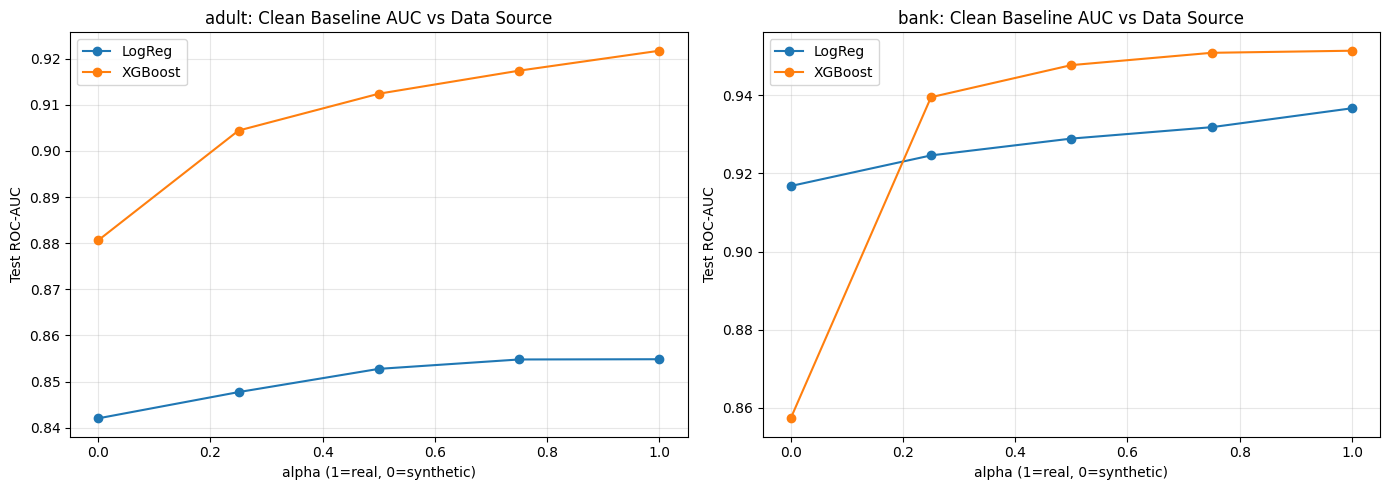

Saved figures/baselines_auc.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, name in enumerate(DATASETS.keys()):
    sub = results_all[results_all['dataset'] == name]
    for mname in CORE_MODELS:
        ms = sub[sub['model'] == mname]
        axes[i].plot(ms['alpha'], ms['test_auc'], marker='o', label=mname)
    axes[i].set_xlabel('alpha (1=real, 0=synthetic)')
    axes[i].set_ylabel('Test ROC-AUC')
    axes[i].set_title(f'{name}: Clean Baseline AUC vs Data Source')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/baselines_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/baselines_auc.png')

## 10. Качество синтетических данных: маргинальные распределения и корреляции

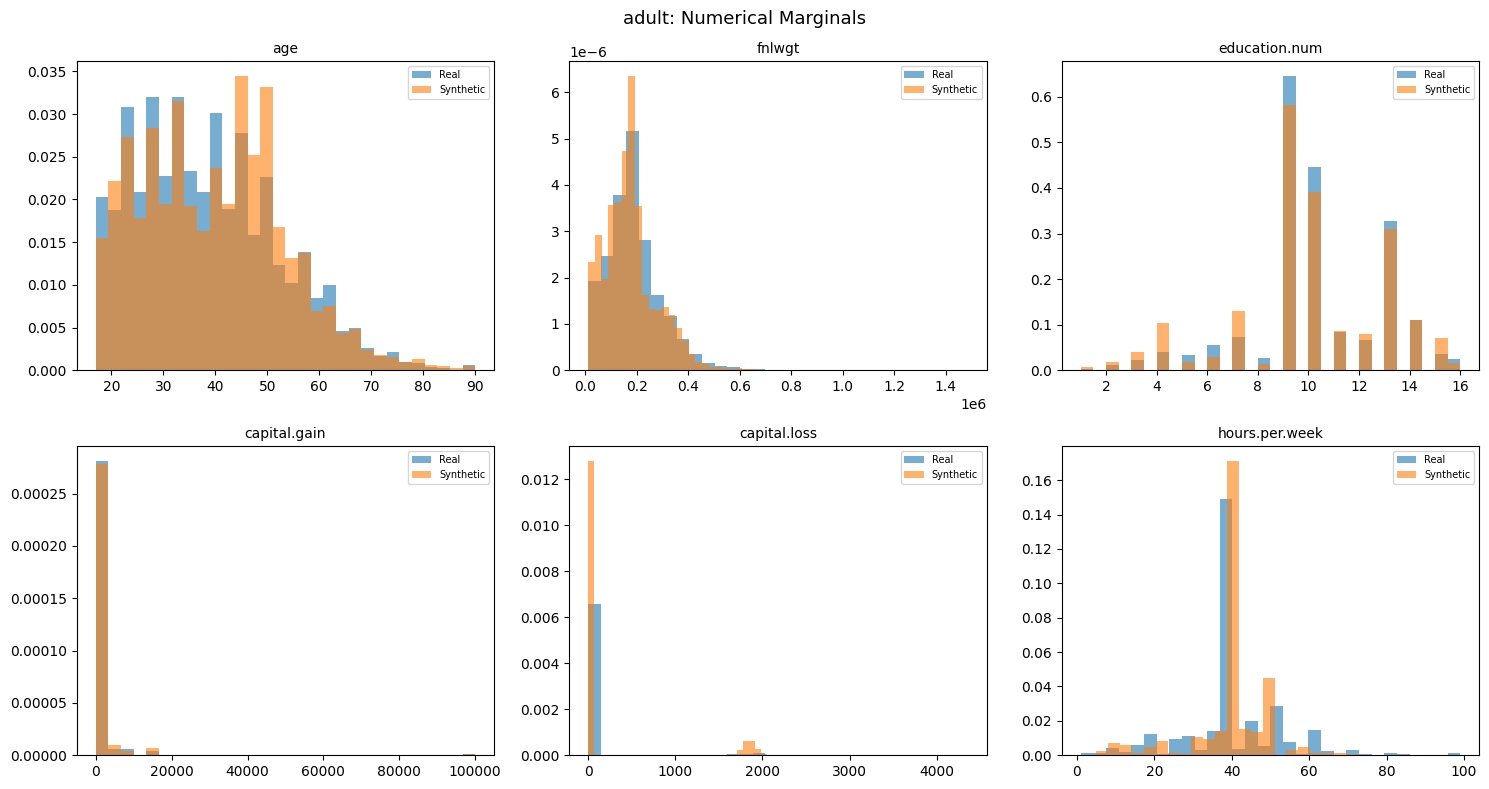

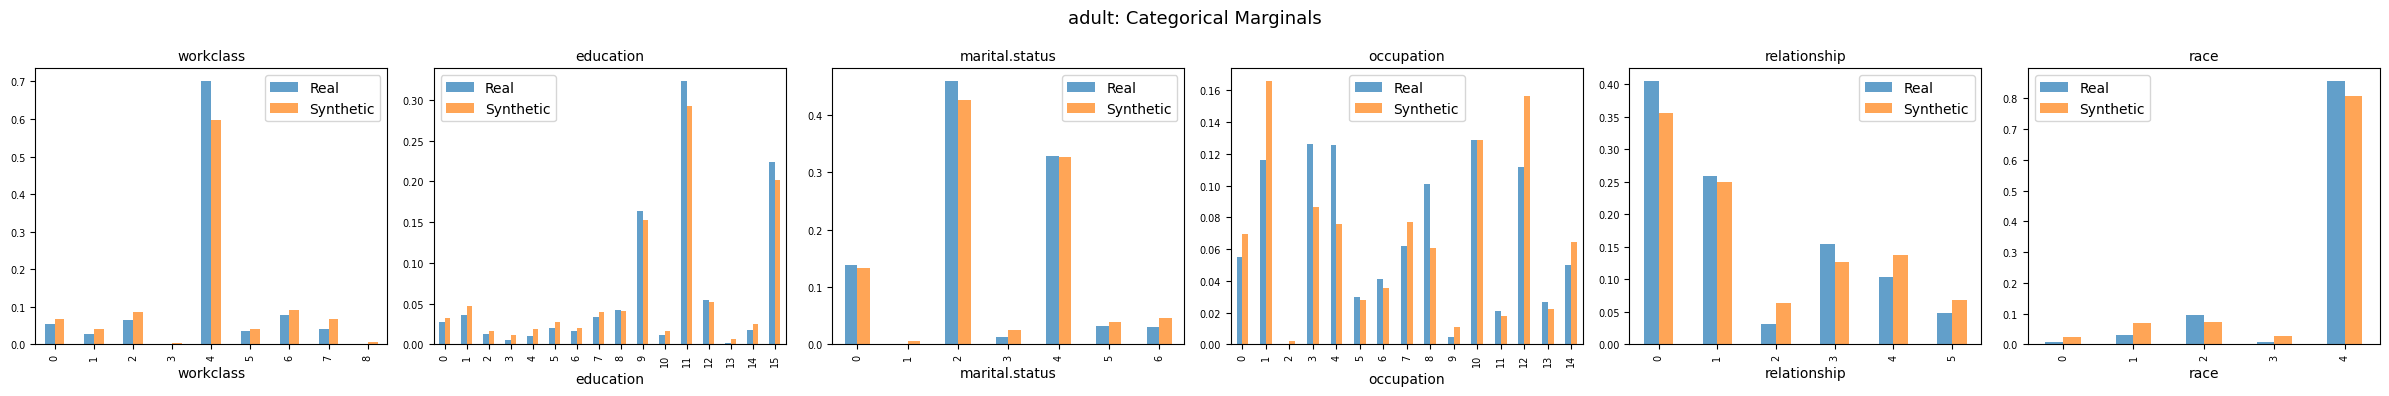

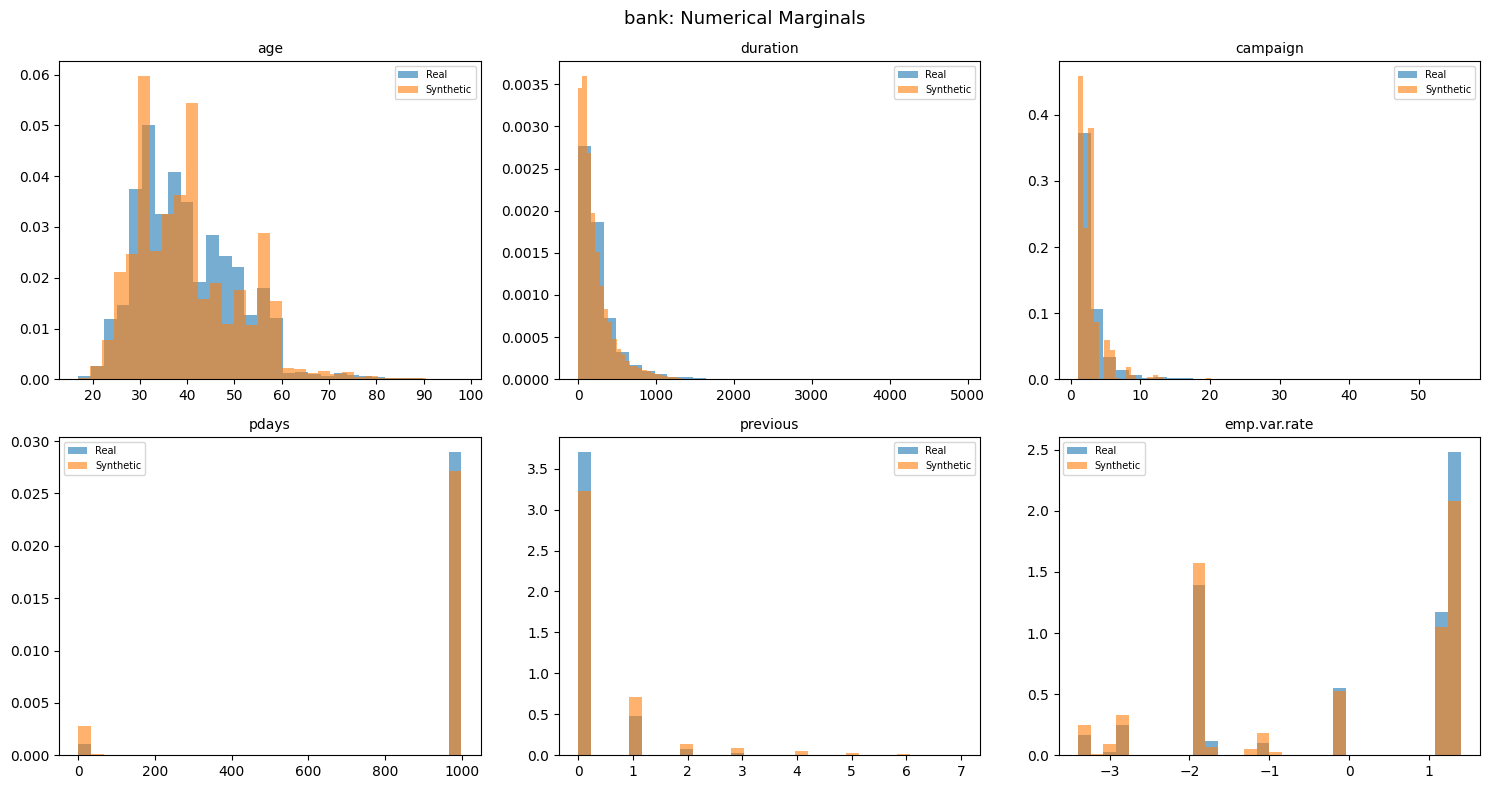

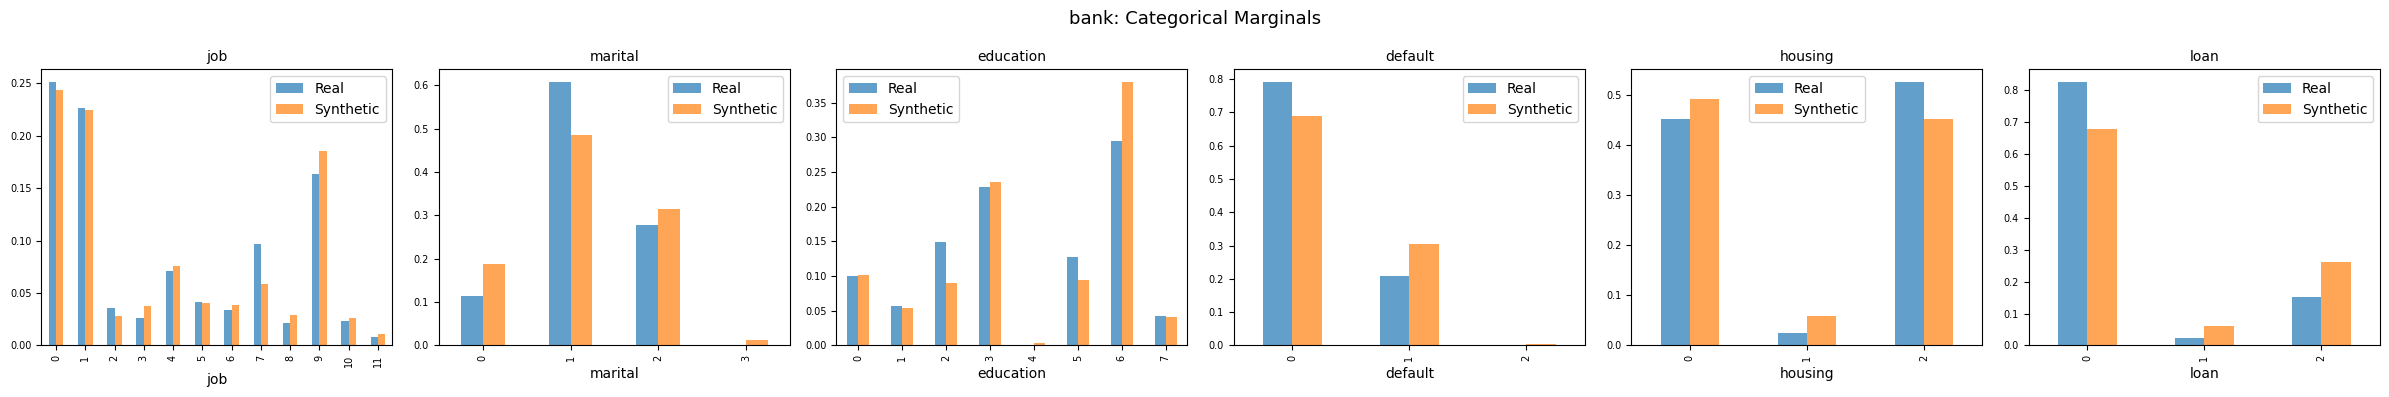

In [ ]:
def plot_marginals(name, target_col):
    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')
    syn_df = pd.read_csv(f'data/synthetic/{name}_syn.csv')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    num_cols = [c for c in meta['num_cols'] if c in train_df.columns][:6]
    cat_cols = [c for c in meta['cat_cols'] if c in train_df.columns][:6]

    if num_cols:
        ncols = min(len(num_cols), 3)
        nrows = (len(num_cols) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        axes = np.array(axes).flatten()
        for j, c in enumerate(num_cols):
            axes[j].hist(train_df[c], bins=30, alpha=0.6, label='Real', density=True)
            axes[j].hist(syn_df[c], bins=30, alpha=0.6, label='Synthetic', density=True)
            axes[j].set_title(c, fontsize=10)
            axes[j].legend(fontsize=7)
        for j in range(len(num_cols), len(axes)):
            axes[j].set_visible(False)
        plt.suptitle(f'{name}: Numerical Marginals', fontsize=13)
        plt.tight_layout()
        plt.savefig(f'figures/{name}_marginals_num.png', dpi=150, bbox_inches='tight')
        plt.show()

    if cat_cols:
        n_cat = len(cat_cols)
        fig, axes = plt.subplots(1, n_cat, figsize=(4*n_cat, 4))
        if n_cat == 1: axes = [axes]
        for j, c in enumerate(cat_cols):
            real_vc = train_df[c].value_counts(normalize=True).sort_index()
            syn_vc  = syn_df[c].value_counts(normalize=True).sort_index()
            combined = pd.DataFrame({'Real': real_vc, 'Synthetic': syn_vc}).fillna(0)
            combined.plot.bar(ax=axes[j], alpha=0.7)
            axes[j].set_title(c, fontsize=10)
            axes[j].tick_params(labelsize=7)
        plt.suptitle(f'{name}: Categorical Marginals', fontsize=13)
        plt.tight_layout()
        plt.savefig(f'figures/{name}_marginals_cat.png', dpi=150, bbox_inches='tight')
        plt.show()

for ds_name, ds_info in DATASETS.items():
    plot_marginals(ds_name, ds_info['target'])

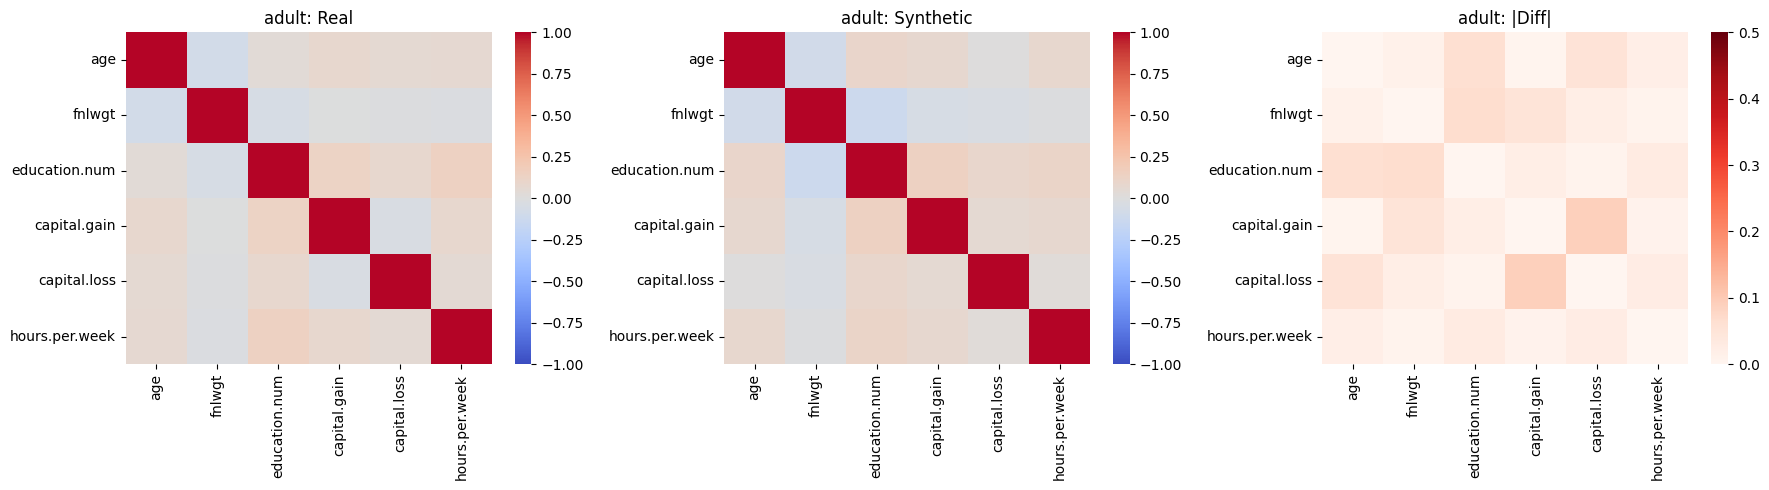

[adult] Mean |corr diff|: 0.0272, Max: 0.0905


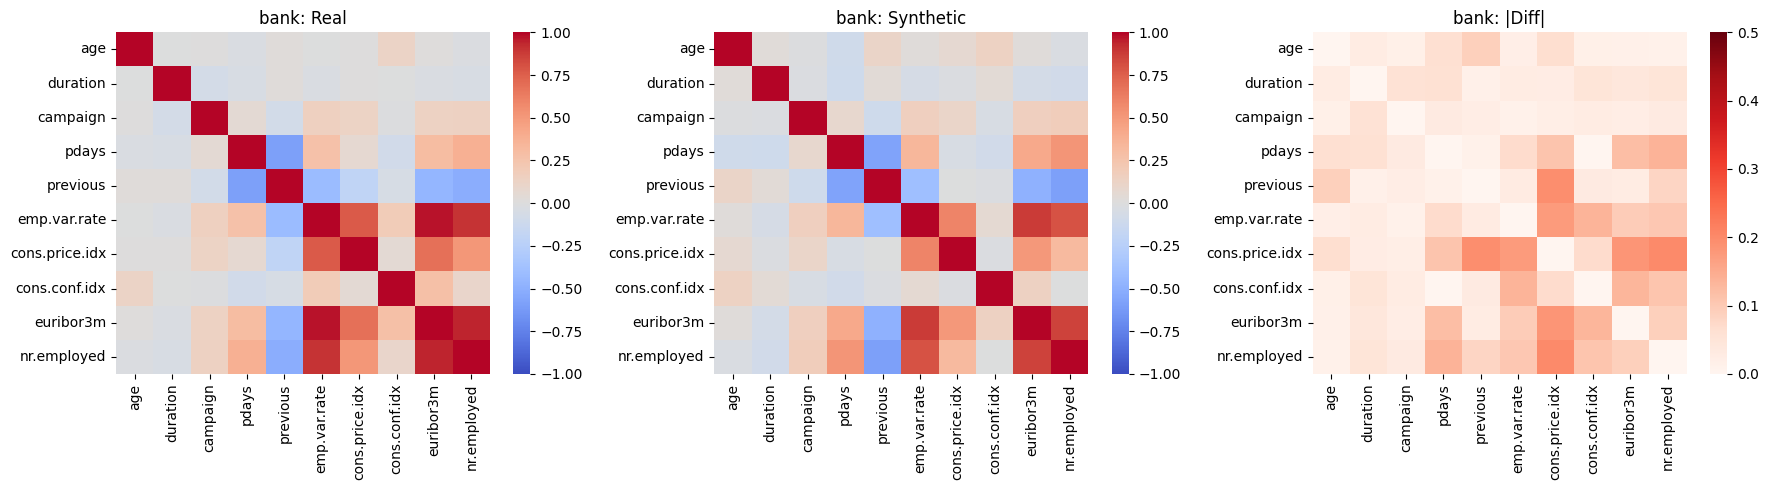

[bank] Mean |corr diff|: 0.0589, Max: 0.2003


In [ ]:
def plot_correlation_comparison(name):
    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')
    syn_df = pd.read_csv(f'data/synthetic/{name}_syn.csv')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    num_cols = [c for c in meta['num_cols'] if c in train_df.columns]
    if len(num_cols) < 2:
        print(f'[{name}] Too few numerical columns')
        return

    corr_real = train_df[num_cols].corr()
    corr_syn  = syn_df[num_cols].corr()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
    axes[0].set_title(f'{name}: Real')
    sns.heatmap(corr_syn, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
    axes[1].set_title(f'{name}: Synthetic')
    sns.heatmap((corr_real - corr_syn).abs(), ax=axes[2], cmap='Reds', vmin=0, vmax=0.5, annot=False)
    axes[2].set_title(f'{name}: |Diff|')
    plt.tight_layout()
    plt.savefig(f'figures/{name}_corr_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    diff = (corr_real - corr_syn).abs()
    print(f'[{name}] Mean |corr diff|: {diff.mean().mean():.4f}, Max: {diff.max().max():.4f}')

for ds_name in DATASETS:
    plot_correlation_comparison(ds_name)

## 11. Core Attack 1: Label Flipping (LF)

Случайный инверс меток для доли $\rho$ обучающих примеров: $y \leftarrow 1 - y$.

In [ ]:
def label_flip(y, rho, seed=SEED):
    rng = np.random.RandomState(seed)
    y_poisoned = y.copy()
    n = len(y)
    n_flip = int(rho * n)
    idx = rng.choice(n, size=n_flip, replace=False)
    y_poisoned[idx] = 1 - y_poisoned[idx]
    return y_poisoned, idx

def run_label_flip_experiment(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0] + POISON_RATES:
            for seed in SEEDS:
                if rho == 0.0:
                    y_tr = y_train.copy()
                else:
                    y_tr, _ = label_flip(y_train, rho, seed=seed)

                for mname, model in get_core_models().items():
                    model.fit(X_train, y_tr)
                    proba = model.predict_proba(X_test)[:, 1]
                    auc = roc_auc_score(y_test, proba)
                    all_results.append({
                        'dataset': name, 'alpha': alpha, 'attack': 'LF',
                        'rho': rho, 'seed': seed, 'model': mname, 'test_auc': auc,
                    })

            print(f'  [{name}] LF alpha={alpha:.2f} rho={rho:.3f} done')

    return pd.DataFrame(all_results)

lf_frames = []
for ds_name in DATASETS:
    lf_frames.append(run_label_flip_experiment(ds_name))

lf_all = pd.concat(lf_frames, ignore_index=True)
lf_all.to_csv('results/label_flip_all.csv', index=False)
print(f'\nTotal LF results: {len(lf_all)} rows. Saved.')

  [adult] LF alpha=0.00 rho=0.000 done
  [adult] LF alpha=0.00 rho=0.005 done
  [adult] LF alpha=0.00 rho=0.010 done
  [adult] LF alpha=0.00 rho=0.020 done
  [adult] LF alpha=0.00 rho=0.050 done
  [adult] LF alpha=0.00 rho=0.100 done
  [adult] LF alpha=0.25 rho=0.000 done
  [adult] LF alpha=0.25 rho=0.005 done
  [adult] LF alpha=0.25 rho=0.010 done
  [adult] LF alpha=0.25 rho=0.020 done
  [adult] LF alpha=0.25 rho=0.050 done
  [adult] LF alpha=0.25 rho=0.100 done
  [adult] LF alpha=0.50 rho=0.000 done
  [adult] LF alpha=0.50 rho=0.005 done
  [adult] LF alpha=0.50 rho=0.010 done
  [adult] LF alpha=0.50 rho=0.020 done
  [adult] LF alpha=0.50 rho=0.050 done
  [adult] LF alpha=0.50 rho=0.100 done
  [adult] LF alpha=0.75 rho=0.000 done
  [adult] LF alpha=0.75 rho=0.005 done
  [adult] LF alpha=0.75 rho=0.010 done
  [adult] LF alpha=0.75 rho=0.020 done
  [adult] LF alpha=0.75 rho=0.050 done
  [adult] LF alpha=0.75 rho=0.100 done
  [adult] LF alpha=1.00 rho=0.000 done
  [adult] LF alpha=1.00 r

## 12. Label Flipping: Degradation Curves

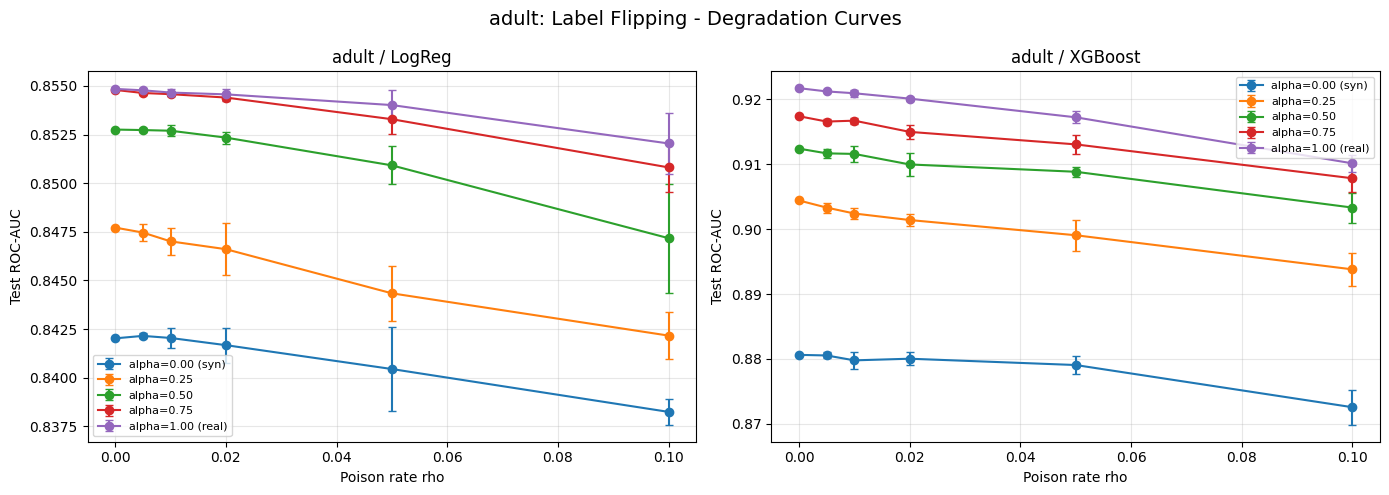

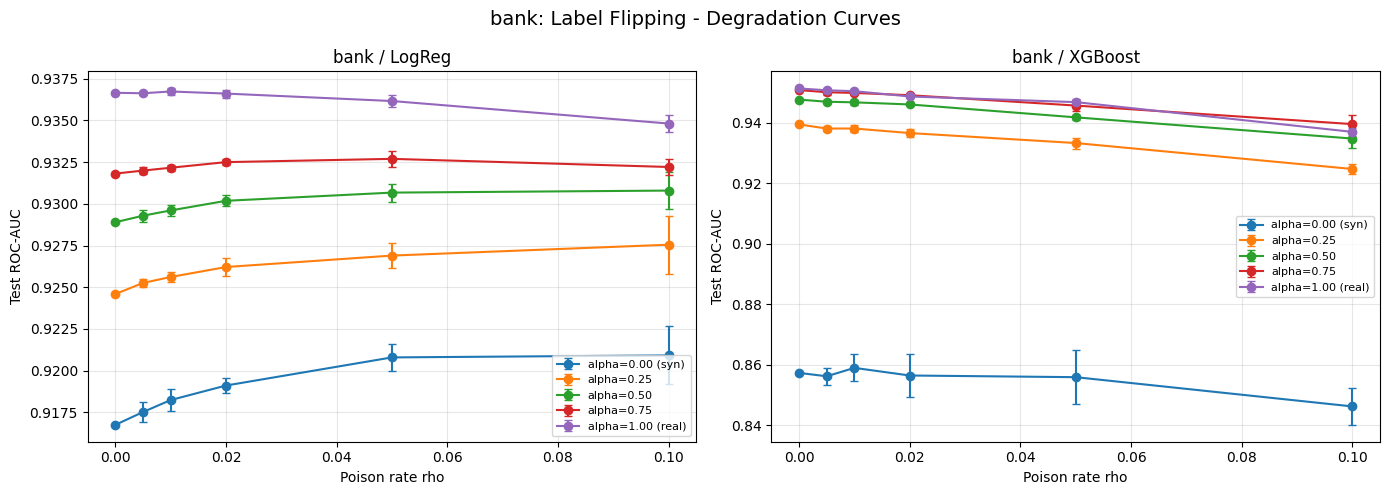

In [ ]:
def plot_degradation_curves(df, attack_name, models=CORE_MODELS):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 5))
        if len(models) == 1: axes = [axes]

        for j, mname in enumerate(models):
            ms = ds[ds['model'] == mname]
            for alpha in ALPHAS:
                sub = ms[ms['alpha'] == alpha].groupby('rho')['test_auc'].agg(['mean', 'std']).reset_index()
                label = f'alpha={alpha:.2f}'
                if alpha == 1.0: label += ' (real)'
                elif alpha == 0.0: label += ' (syn)'
                axes[j].errorbar(sub['rho'], sub['mean'], yerr=sub['std'],
                                 marker='o', capsize=3, label=label)
            axes[j].set_xlabel('Poison rate rho')
            axes[j].set_ylabel('Test ROC-AUC')
            axes[j].set_title(f'{name} / {mname}')
            axes[j].legend(fontsize=8)
            axes[j].grid(True, alpha=0.3)

        plt.suptitle(f'{name}: {attack_name} - Degradation Curves', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/{name}_{attack_name.lower().replace(" ", "_")}_curves.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

plot_degradation_curves(lf_all, 'Label Flipping')

In [ ]:
def degradation_summary(df, attack_label=''):
    clean = df[df['rho'] == 0.0].groupby(['dataset', 'model', 'alpha'])['test_auc'].mean()
    worst = df[df['rho'] == 0.10].groupby(['dataset', 'model', 'alpha'])['test_auc'].mean()
    delta = (clean - worst).reset_index()
    delta.columns = ['dataset', 'model', 'alpha', 'auc_drop']
    delta = delta.sort_values(['dataset', 'model', 'alpha'])
    print(f'AUC drop (clean -> rho=10%) {attack_label}:')
    print(delta.to_string(index=False))
    return delta

lf_summary = degradation_summary(lf_all, '[LF]')
lf_summary.to_csv('results/label_flip_summary.csv', index=False)

AUC drop (clean -> rho=10%) [LF]:
dataset   model  alpha  auc_drop
  adult  LogReg   0.00  0.003778
  adult  LogReg   0.25  0.005549
  adult  LogReg   0.50  0.005580
  adult  LogReg   0.75  0.003981
  adult  LogReg   1.00  0.002801
  adult XGBoost   0.00  0.008069
  adult XGBoost   0.25  0.010616
  adult XGBoost   0.50  0.009085
  adult XGBoost   0.75  0.009565
  adult XGBoost   1.00  0.011586
   bank  LogReg   0.00 -0.004162
   bank  LogReg   0.25 -0.002959
   bank  LogReg   0.50 -0.001898
   bank  LogReg   0.75 -0.000396
   bank  LogReg   1.00  0.001842
   bank XGBoost   0.00  0.011085
   bank XGBoost   0.25  0.014733
   bank XGBoost   0.50  0.012886
   bank XGBoost   0.75  0.011257
   bank XGBoost   1.00  0.014357


## 13. Основная Аттака 2: Feature Perturbation (FP)

Perturbation для доли $\rho$ обучающих примеров:
- Числовые: $x_j \leftarrow x_j + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\, \lambda^2)$
- Категориальные: замена на случайную допустимую категорию

$\lambda \in \{0.5,\ 1.0,\ 2.0\}$ управляет силой изменения.

In [ ]:
def feature_perturb(X, y, rho, lam, meta, seed=SEED):
    rng = np.random.RandomState(seed)
    X_p = X.copy()
    n = len(X)
    n_poison = int(rho * n)
    idx = rng.choice(n, size=n_poison, replace=False)

    num_idx = meta['num_idx']
    cat_idx = meta['cat_idx']

    if len(num_idx) > 0:
        noise = rng.normal(0, lam, size=(n_poison, len(num_idx)))
        X_p[idx[:, None], num_idx] += noise

    if len(cat_idx) > 0:
        for i in idx:
            col = rng.choice(cat_idx)
            vals = np.unique(X[:, col])
            X_p[i, col] = rng.choice(vals)

    return X_p, idx

def run_fp_experiment(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0] + POISON_RATES:
            for lam in (LAMBDAS if rho > 0 else [0.0]):
                for seed in SEEDS:
                    if rho == 0.0:
                        X_tr = X_train.copy()
                    else:
                        X_tr, _ = feature_perturb(X_train, y_train, rho, lam, meta, seed)

                    for mname, model in get_core_models().items():
                        model.fit(X_tr, y_train)
                        proba = model.predict_proba(X_test)[:, 1]
                        auc = roc_auc_score(y_test, proba)
                        all_results.append({
                            'dataset': name, 'alpha': alpha, 'attack': 'FP',
                            'rho': rho, 'lambda': lam, 'seed': seed,
                            'model': mname, 'test_auc': auc,
                        })

                print(f'  [{name}] FP alpha={alpha:.2f} rho={rho:.3f} lambda={lam} done')

    return pd.DataFrame(all_results)

fp_frames = []
for ds_name in DATASETS:
    fp_frames.append(run_fp_experiment(ds_name))

fp_all = pd.concat(fp_frames, ignore_index=True)
fp_all.to_csv('results/feature_perturb_all.csv', index=False)
print(f'\nTotal FP results: {len(fp_all)} rows. Saved.')

  [adult] FP alpha=0.00 rho=0.000 lambda=0.0 done
  [adult] FP alpha=0.00 rho=0.005 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.005 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.005 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.010 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.010 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.010 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.020 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.020 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.020 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.050 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.050 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.050 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.100 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.100 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.100 lambda=2.0 done
  [adult] FP alpha=0.25 rho=0.000 lambda=0.0 done
  [adult] FP alpha=0.25 rho=0.005 lambda=0.5 done
  [adult] FP alpha=0.25 rho=0.005 lambda=1.0 done
  [adult] FP alpha=0.25 rho=0.005 lambda=2.0 done


## 14. Feature Perturbation: кривые деградации

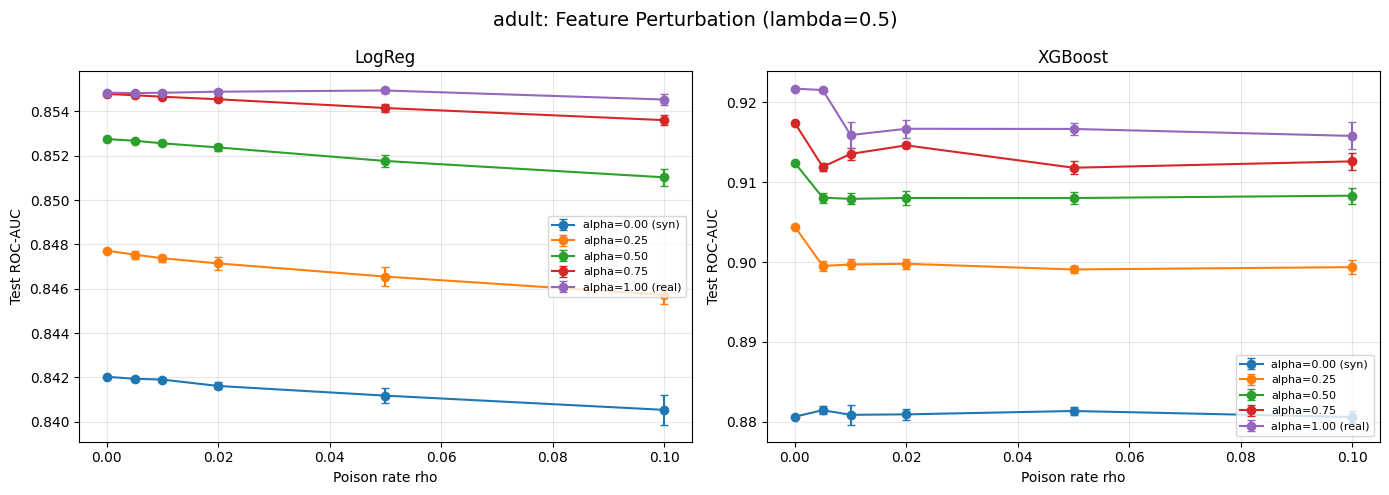

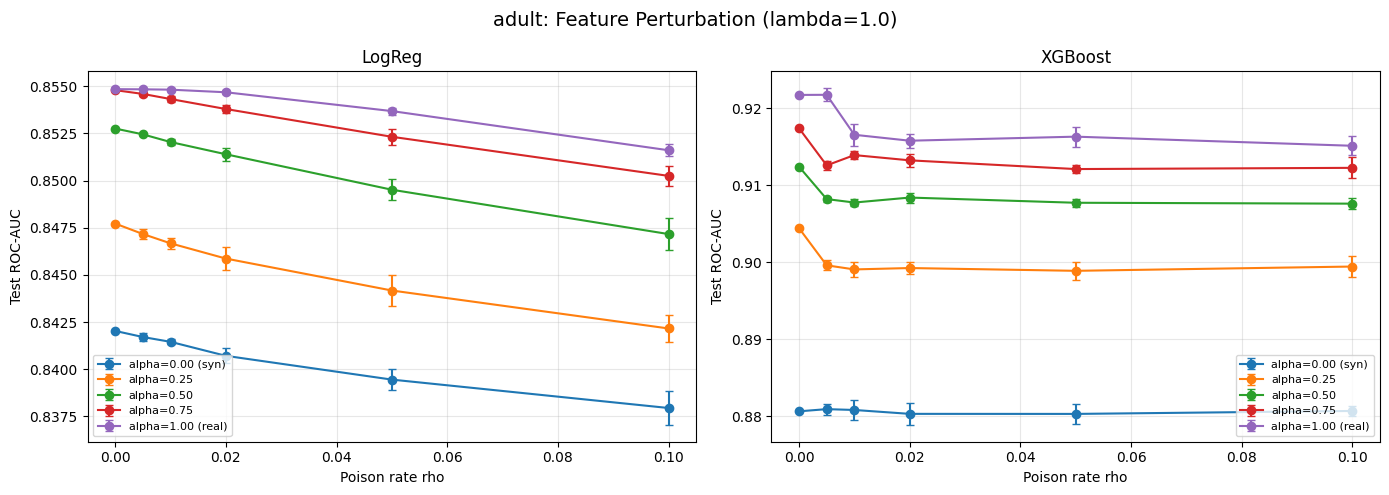

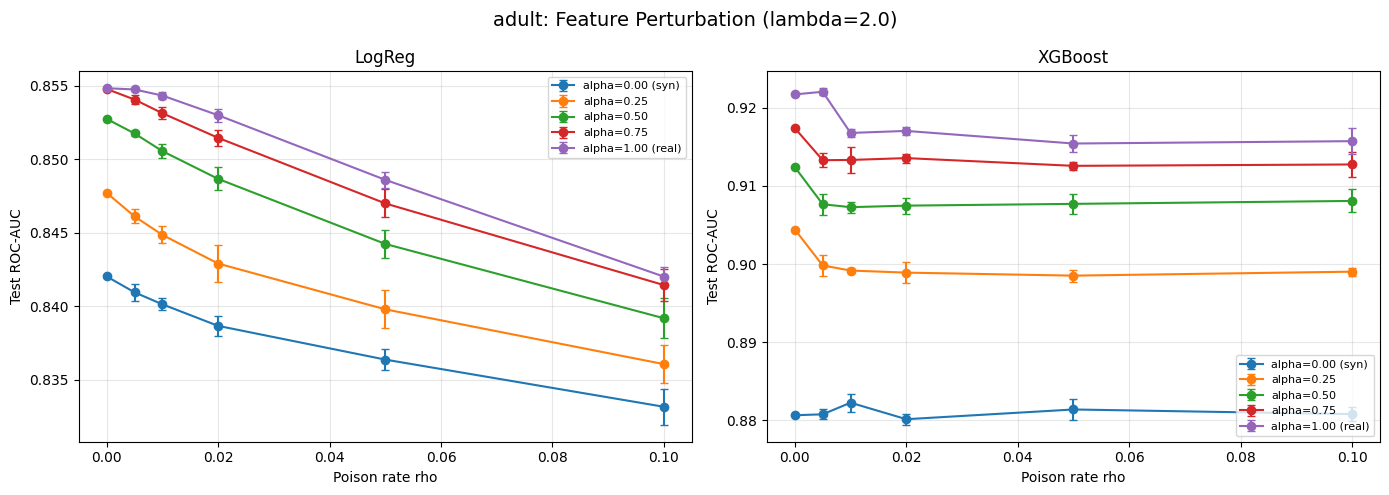

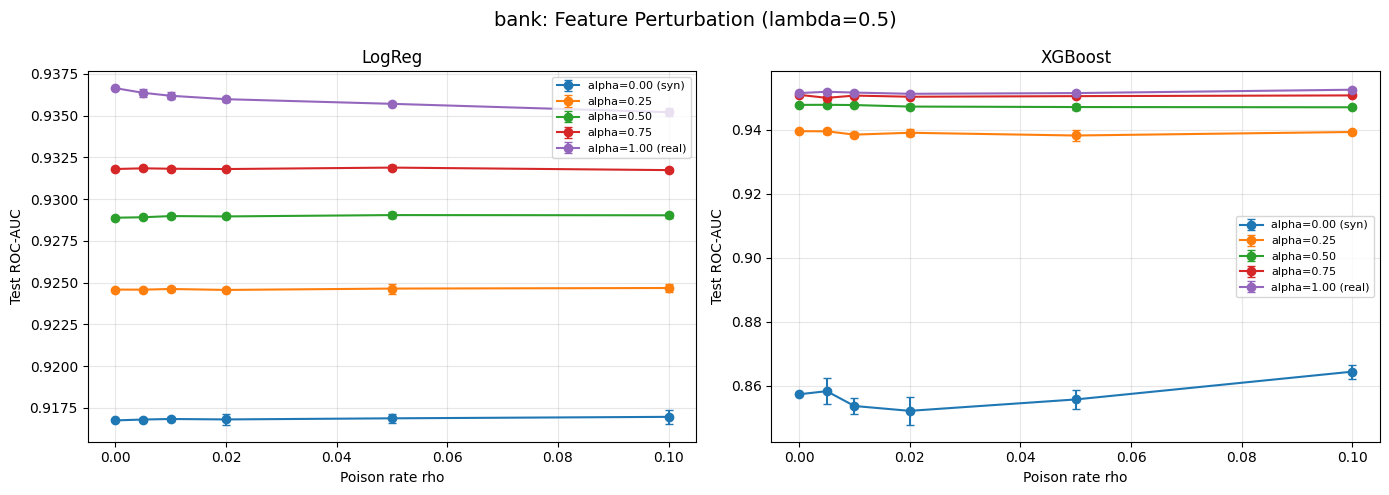

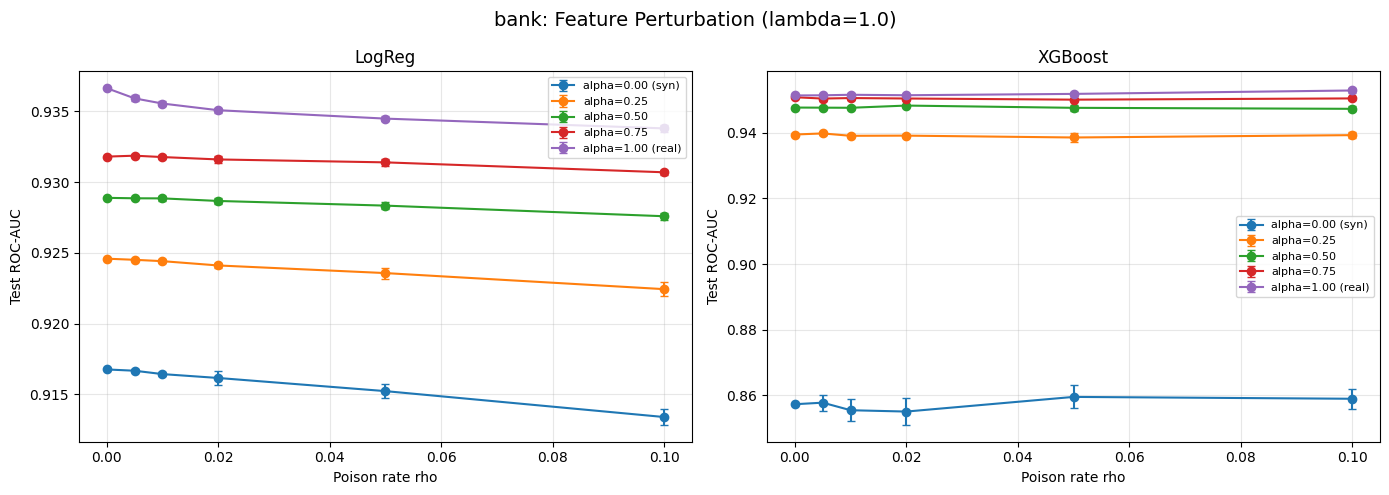

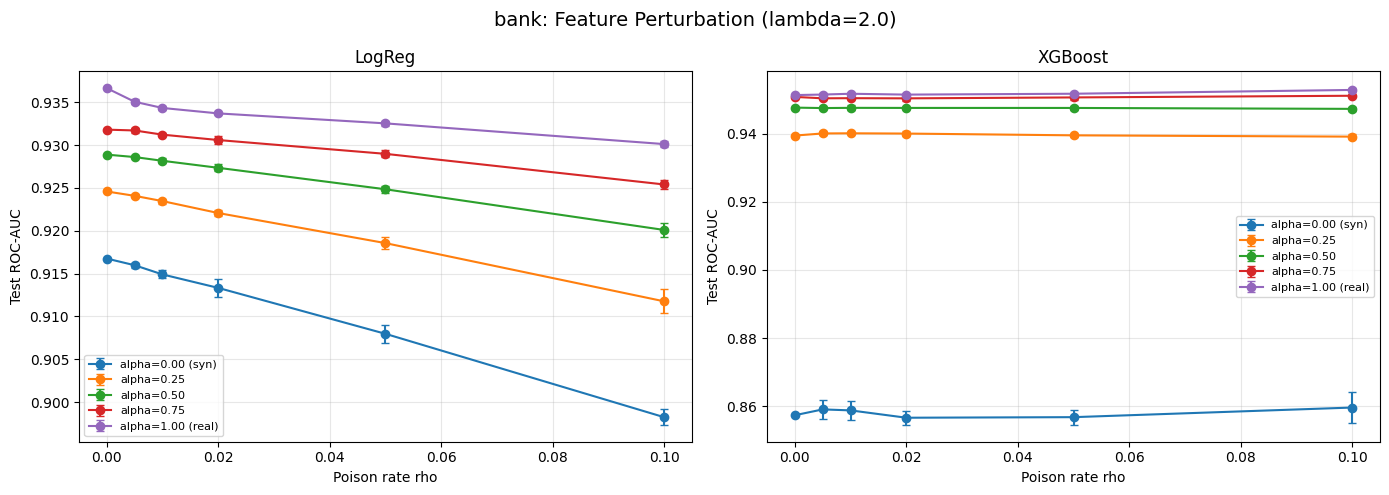

In [ ]:
def plot_fp_curves(df, models=CORE_MODELS):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        for lam in LAMBDAS:
            sub = ds[(ds['lambda'] == lam) | (ds['rho'] == 0.0)].copy()
            sub.loc[sub['rho'] == 0.0, 'lambda'] = lam

            fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 5))
            if len(models) == 1: axes = [axes]

            for j, mname in enumerate(models):
                ms = sub[sub['model'] == mname]
                for alpha in ALPHAS:
                    s = ms[ms['alpha'] == alpha].groupby('rho')['test_auc'].agg(['mean', 'std']).reset_index()
                    label = f'alpha={alpha:.2f}'
                    if alpha == 1.0: label += ' (real)'
                    elif alpha == 0.0: label += ' (syn)'
                    axes[j].errorbar(s['rho'], s['mean'], yerr=s['std'],
                                     marker='o', capsize=3, label=label)
                axes[j].set_xlabel('Poison rate rho')
                axes[j].set_ylabel('Test ROC-AUC')
                axes[j].set_title(f'{mname}')
                axes[j].legend(fontsize=8)
                axes[j].grid(True, alpha=0.3)

            plt.suptitle(f'{name}: Feature Perturbation (lambda={lam})', fontsize=14)
            plt.tight_layout()
            plt.savefig(f'figures/{name}_fp_lam{lam}_curves.png', dpi=150, bbox_inches='tight')
            plt.show()

plot_fp_curves(fp_all)

In [ ]:
for lam in LAMBDAS:
    sub = fp_all[(fp_all['lambda'].isin([lam, 0.0]))].copy()
    sub.loc[sub['rho'] == 0.0, 'lambda'] = lam
    sub_lam = sub[sub['lambda'] == lam]
    print(f'\nlambda = {lam} ')
    degradation_summary(sub_lam, f'[FP lambda={lam}]')

fp_lam1 = fp_all[(fp_all['lambda'].isin([1.0, 0.0]))].copy()
fp_lam1.loc[fp_lam1['rho'] == 0.0, 'lambda'] = 1.0
fp_summary = degradation_summary(fp_lam1, '[FP lambda=1.0]')
fp_summary.to_csv('results/feature_perturb_summary.csv', index=False)


lambda = 0.5 
AUC drop (clean -> rho=10%) [FP lambda=0.5]:
dataset   model  alpha  auc_drop
  adult  LogReg   0.00  0.001493
  adult  LogReg   0.25  0.001992
  adult  LogReg   0.50  0.001726
  adult  LogReg   0.75  0.001183
  adult  LogReg   1.00  0.000305
  adult XGBoost   0.00  0.000053
  adult XGBoost   0.25  0.005063
  adult XGBoost   0.50  0.004095
  adult XGBoost   0.75  0.004797
  adult XGBoost   1.00  0.005927
   bank  LogReg   0.00 -0.000213
   bank  LogReg   0.25 -0.000095
   bank  LogReg   0.50 -0.000145
   bank  LogReg   0.75  0.000066
   bank  LogReg   1.00  0.001439
   bank XGBoost   0.00 -0.007070
   bank XGBoost   0.25  0.000245
   bank XGBoost   0.50  0.000743
   bank XGBoost   0.75  0.000186
   bank XGBoost   1.00 -0.001055

lambda = 1.0 
AUC drop (clean -> rho=10%) [FP lambda=1.0]:
dataset   model  alpha  auc_drop
  adult  LogReg   0.00  0.004086
  adult  LogReg   0.25  0.005560
  adult  LogReg   0.50  0.005593
  adult  LogReg   0.75  0.004545
  adult  LogReg   1.00

## 15. Итоговые таблицы основного бенчмарка

### Сводная таблица: AUC ($\text{mean} \pm \text{std}$) при ключевых значениях $\rho$

In [ ]:
def build_summary_table(df, rho_values=[0.0, 0.02, 0.05, 0.10]):
    rows = []
    for name in df['dataset'].unique():
        for mname in CORE_MODELS:
            for alpha in ALPHAS:
                sub = df[(df['dataset']==name) & (df['model']==mname) & (df['alpha']==alpha)]
                row = {'dataset': name, 'model': mname, 'alpha': alpha}
                for rho in rho_values:
                    vals = sub[sub['rho']==rho]['test_auc']
                    if len(vals) > 0:
                        row[f'rho={rho}'] = f'{vals.mean():.4f}+/-{vals.std():.4f}'
                    else:
                        row[f'rho={rho}'] = '-'
                rows.append(row)
    return pd.DataFrame(rows)

print('  CORE BENCHMARK: LABEL FLIPPING')
lf_table = build_summary_table(lf_all)
print(lf_table.to_string(index=False))

print('\n' + '=' * 80)
print('CORE BENCHMARK: FEATURE PERTURBATION (lambda=1.0)')
fp_sub = fp_all[(fp_all['lambda'].isin([1.0, 0.0]))].copy()
fp_sub.loc[fp_sub['rho'] == 0.0, 'lambda'] = 1.0
fp_table = build_summary_table(fp_sub)
print(fp_table.to_string(index=False))

lf_table.to_csv('results/core_summary_lf.csv', index=False)
fp_table.to_csv('results/core_summary_fp.csv', index=False)
print('\nSaved core summary tables.')

  CORE BENCHMARK: LABEL FLIPPING
dataset   model  alpha         rho=0.0        rho=0.02        rho=0.05         rho=0.1
  adult  LogReg   0.00 0.8420+/-0.0000 0.8417+/-0.0009 0.8405+/-0.0022 0.8382+/-0.0007
  adult  LogReg   0.25 0.8477+/-0.0000 0.8466+/-0.0013 0.8443+/-0.0014 0.8422+/-0.0012
  adult  LogReg   0.50 0.8528+/-0.0000 0.8523+/-0.0003 0.8509+/-0.0010 0.8472+/-0.0028
  adult  LogReg   0.75 0.8548+/-0.0000 0.8544+/-0.0002 0.8533+/-0.0007 0.8508+/-0.0013
  adult  LogReg   1.00 0.8548+/-0.0000 0.8546+/-0.0003 0.8540+/-0.0008 0.8520+/-0.0016
  adult XGBoost   0.00 0.8806+/-0.0000 0.8800+/-0.0010 0.8791+/-0.0013 0.8726+/-0.0027
  adult XGBoost   0.25 0.9044+/-0.0000 0.9014+/-0.0010 0.8991+/-0.0024 0.8938+/-0.0025
  adult XGBoost   0.50 0.9124+/-0.0000 0.9100+/-0.0018 0.9088+/-0.0008 0.9033+/-0.0023
  adult XGBoost   0.75 0.9174+/-0.0000 0.9150+/-0.0010 0.9131+/-0.0015 0.9078+/-0.0021
  adult XGBoost   1.00 0.9217+/-0.0000 0.9201+/-0.0003 0.9172+/-0.0009 0.9101+/-0.0013
   bank  L

## 16. Сравнение уязвимости: реальные vs синтетические данные

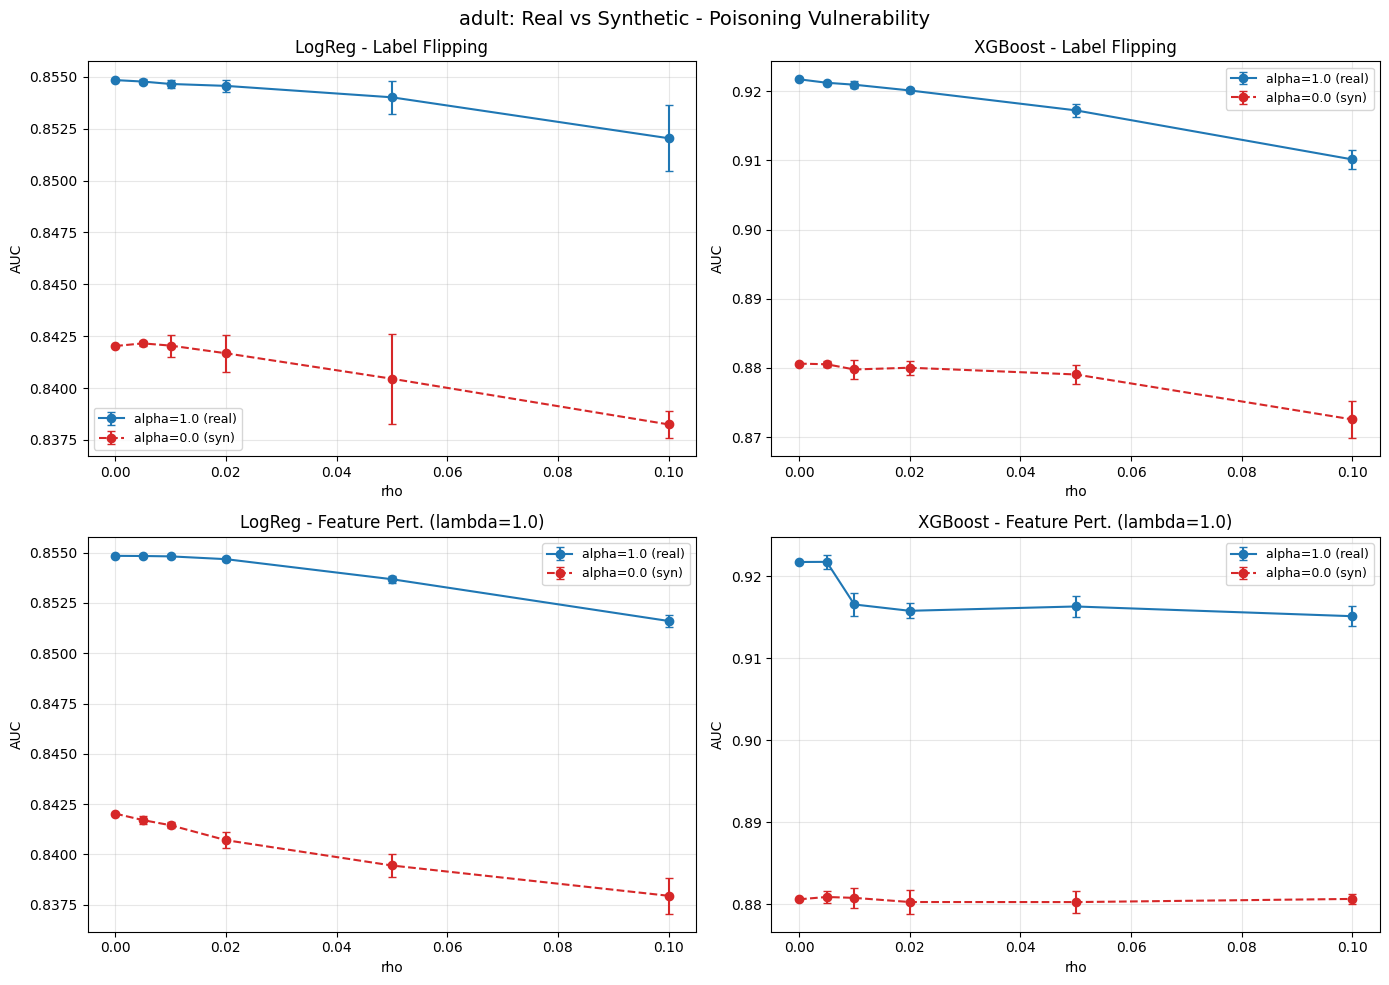

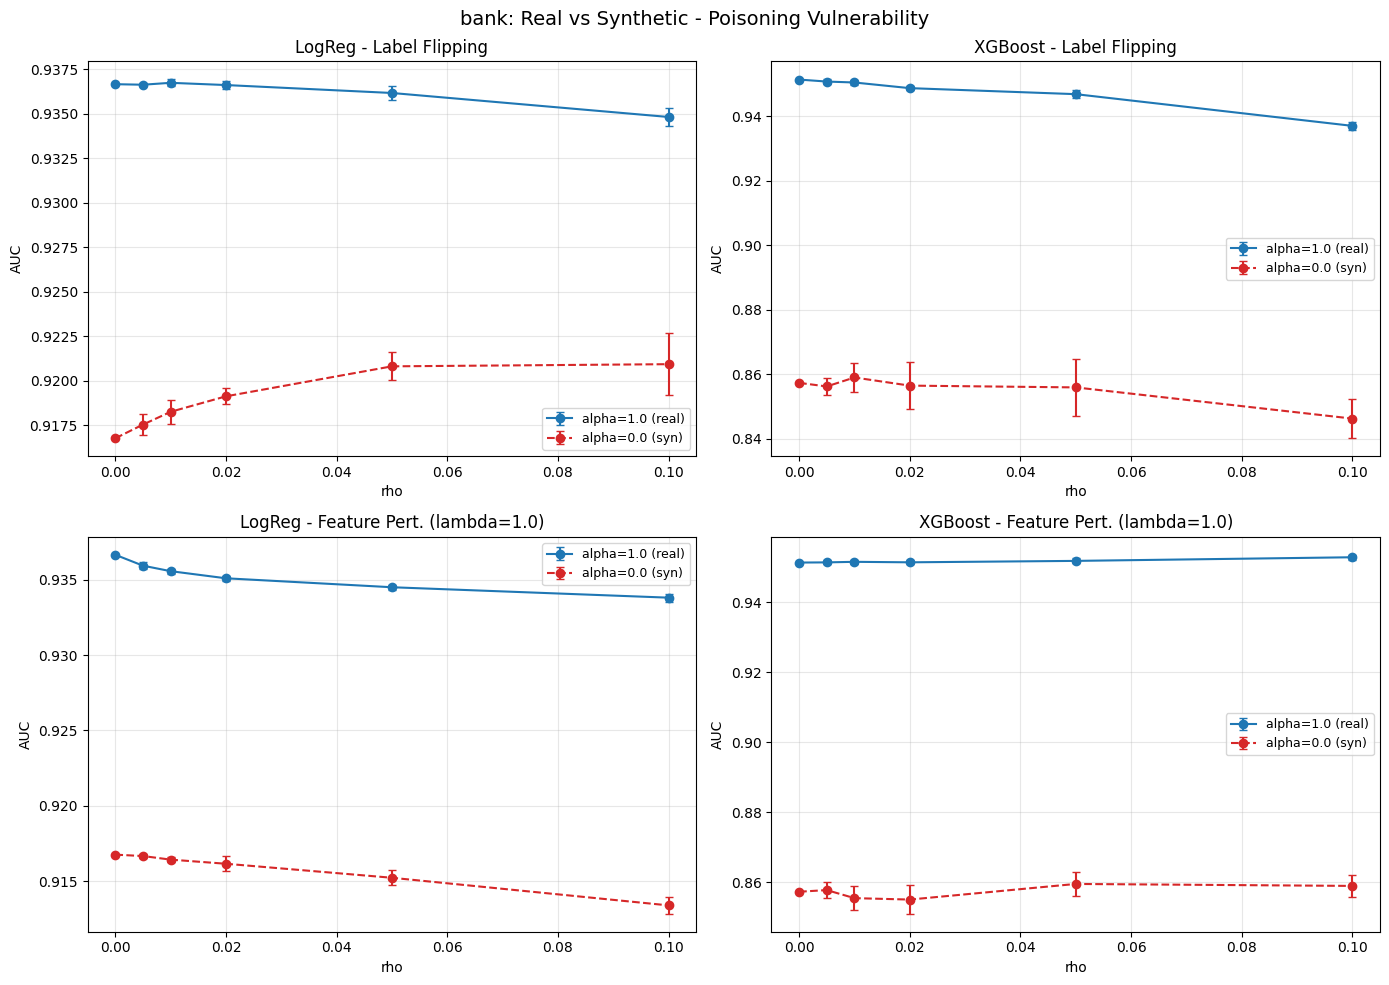

In [ ]:
def plot_real_vs_syn_comparison(lf_df, fp_df):
    for name in lf_df['dataset'].unique():
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        for j, mname in enumerate(CORE_MODELS):
            # LF
            for alpha, color, ls in [(1.0, 'tab:blue', '-'), (0.0, 'tab:red', '--')]:
                sub = lf_df[(lf_df['dataset']==name) & (lf_df['model']==mname) & (lf_df['alpha']==alpha)]
                agg = sub.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                label = f'alpha={alpha:.1f} ({"real" if alpha==1.0 else "syn"})'
                axes[0, j].errorbar(agg['rho'], agg['mean'], yerr=agg['std'],
                                    marker='o', capsize=3, label=label, color=color, linestyle=ls)
            axes[0, j].set_title(f'{mname} - Label Flipping')
            axes[0, j].set_xlabel('rho'); axes[0, j].set_ylabel('AUC')
            axes[0, j].legend(fontsize=9); axes[0, j].grid(True, alpha=0.3)

            # FP (lambda=1.0)
            fp_sub = fp_df[(fp_df['lambda'].isin([1.0, 0.0]))].copy()
            fp_sub.loc[fp_sub['rho'] == 0.0, 'lambda'] = 1.0
            for alpha, color, ls in [(1.0, 'tab:blue', '-'), (0.0, 'tab:red', '--')]:
                sub = fp_sub[(fp_sub['dataset']==name) & (fp_sub['model']==mname) & (fp_sub['alpha']==alpha)]
                agg = sub.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                label = f'alpha={alpha:.1f} ({"real" if alpha==1.0 else "syn"})'
                axes[1, j].errorbar(agg['rho'], agg['mean'], yerr=agg['std'],
                                    marker='o', capsize=3, label=label, color=color, linestyle=ls)
            axes[1, j].set_title(f'{mname} - Feature Pert. (lambda=1.0)')
            axes[1, j].set_xlabel('rho'); axes[1, j].set_ylabel('AUC')
            axes[1, j].legend(fontsize=9); axes[1, j].grid(True, alpha=0.3)

        plt.suptitle(f'{name}: Real vs Synthetic - Poisoning Vulnerability', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/{name}_real_vs_syn_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_real_vs_syn_comparison(lf_all, fp_all)

## 17. Интерпретация основных результатов

In [ ]:
def interpret_results(lf_df, fp_df):
    print('INTERPRETATION OF CORE BENCHMARK RESULTS')

    for name in lf_df['dataset'].unique():
        print(f'Dataset: {name}')

        for mname in CORE_MODELS:
            print(f'\nModel: {mname}')

            # LF analysis
            for alpha in [0.0, 1.0]:
                sub = lf_df[(lf_df['dataset']==name) & (lf_df['model']==mname) & (lf_df['alpha']==alpha)]
                clean_auc = sub[sub['rho']==0.0]['test_auc'].mean()
                worst_auc = sub[sub['rho']==0.10]['test_auc'].mean()
                drop = clean_auc - worst_auc
                tag = 'real' if alpha == 1.0 else 'synthetic'
                print(f'    LF [{tag}]: clean={clean_auc:.4f}, rho=10%={worst_auc:.4f}, drop={drop:.4f}')

            # FP analysis
            fp_sub = fp_df[(fp_df['lambda'].isin([1.0, 0.0]))].copy()
            fp_sub.loc[fp_sub['rho'] == 0.0, 'lambda'] = 1.0
            for alpha in [0.0, 1.0]:
                sub = fp_sub[(fp_sub['dataset']==name) & (fp_sub['model']==mname) & (fp_sub['alpha']==alpha)]
                clean_auc = sub[sub['rho']==0.0]['test_auc'].mean()
                worst_auc = sub[sub['rho']==0.10]['test_auc'].mean()
                drop = clean_auc - worst_auc
                tag = 'real' if alpha == 1.0 else 'synthetic'
                print(f'    FP [{tag}]: clean={clean_auc:.4f}, rho=10%={worst_auc:.4f}, drop={drop:.4f}')

            # H1 check
            r = lf_df[(lf_df['dataset']==name) & (lf_df['model']==mname) & (lf_df['alpha']==1.0)]
            s = lf_df[(lf_df['dataset']==name) & (lf_df['model']==mname) & (lf_df['alpha']==0.0)]
            r_drop = r[r['rho']==0.0]['test_auc'].mean() - r[r['rho']==0.10]['test_auc'].mean()
            s_drop = s[s['rho']==0.0]['test_auc'].mean() - s[s['rho']==0.10]['test_auc'].mean()
            verdict = 'DIFFERENT' if abs(r_drop - s_drop) > 0.005 else 'SIMILAR'
            print(f'-> H1 (LF): real_drop={r_drop:.4f}, syn_drop={s_drop:.4f} -> {verdict}')

interpret_results(lf_all, fp_all)

INTERPRETATION OF CORE BENCHMARK RESULTS
Dataset: adult

Model: LogReg
    LF [synthetic]: clean=0.8420, rho=10%=0.8382, drop=0.0038
    LF [real]: clean=0.8548, rho=10%=0.8520, drop=0.0028
    FP [synthetic]: clean=0.8420, rho=10%=0.8379, drop=0.0041
    FP [real]: clean=0.8548, rho=10%=0.8516, drop=0.0032
-> H1 (LF): real_drop=0.0028, syn_drop=0.0038 -> SIMILAR

Model: XGBoost
    LF [synthetic]: clean=0.8806, rho=10%=0.8726, drop=0.0081
    LF [real]: clean=0.9217, rho=10%=0.9101, drop=0.0116
    FP [synthetic]: clean=0.8806, rho=10%=0.8807, drop=-0.0000
    FP [real]: clean=0.9217, rho=10%=0.9151, drop=0.0066
-> H1 (LF): real_drop=0.0116, syn_drop=0.0081 -> SIMILAR
Dataset: bank

Model: LogReg
    LF [synthetic]: clean=0.9168, rho=10%=0.9209, drop=-0.0042
    LF [real]: clean=0.9366, rho=10%=0.9348, drop=0.0018
    FP [synthetic]: clean=0.9168, rho=10%=0.9134, drop=0.0034
    FP [real]: clean=0.9366, rho=10%=0.9338, drop=0.0028
-> H1 (LF): real_drop=0.0018, syn_drop=-0.0042 -> DIFF

---

# Дополнительные эксперименты

Разделы ниже не входят в основной бенчмарк, а предоставляют дополнительные данные.
Они включают: backdoor-атаки, baseline-защиты, privacy-метрики.

## A1. Опционально: Backdoor Poisoning (BD)

## Sanity-check триггерного паттерна

Согласно методологии BD-атак, триггер должен быть редким и не должен сам по себе коррелировать с целевой меткой в реальных данных. Иначе высокий ASR при $\rho=0$ означает, что мы измеряем не успех бэкдора, а статистическую связь признаков с target. Здесь проверяем эти свойства.

In [11]:
def trigger_sanity_check(name, target_label=1):
    """Проверка триггера: редкость и корреляция с y в чистых данных."""
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    X_train = np.load(f'data/processed/{name}/X_train.npy')
    y_train = np.load(f'data/processed/{name}/y_train.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    tol = 0.1  # tolerance for "approximately matches trigger"

    print(f'[{name}] Trigger sanity check')
    print(f'Trigger cols: {[meta["feature_names"][c] for c in trigger_cols]}')
    print(f'Trigger vals (scaled): {trigger_vals}')

    # Frequency of the trigger pattern in clean train and test
    for split_name, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
        matches = np.all(np.abs(X[:, trigger_cols] - trigger_vals) < tol, axis=1)
        freq = matches.mean()
        if matches.sum() > 0:
            y_freq = y[matches].mean()
        else:
            y_freq = float('nan')
        print(f'  [{split_name}] natural trigger frequency = {freq:.4f}, '
              f'P(y=1 | trigger) = {y_freq:.4f} (vs base rate {y.mean():.4f})')

    # Target class distribution in test
    target_rate = (y_test == target_label).mean()
    print(f'  Test base rate for target label y={target_label}: {target_rate:.4f}')
    print(f'  -> baseline (chance) ASR is approximately {target_rate:.4f}')
    print()

for ds_name in ['adult', 'bank']:
    trigger_sanity_check(ds_name)

[adult] Trigger sanity check
Trigger cols: ['age', 'fnlwgt']
Trigger vals (scaled): [3.0, 3.0]
  [train] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.2408)
  [test] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.2407)
  Test base rate for target label y=1: 0.2407
  -> baseline (chance) ASR is approximately 0.2407

[bank] Trigger sanity check
Trigger cols: ['age', 'duration']
Trigger vals (scaled): [3.0, 3.0]
  [train] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.1127)
  [test] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.1126)
  Test base rate for target label y=1: 0.1126
  -> baseline (chance) ASR is approximately 0.1126



In [12]:
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed

def backdoor_poison(X, y, rho, meta, target_label=1, seed=SEED):
    rng = np.random.RandomState(seed)
    X_p = X.copy()
    y_p = y.copy()
    n = len(X)
    n_poison = int(rho * n)
    idx = rng.choice(n, size=n_poison, replace=False)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)

    for i in idx:
        for col, val in zip(trigger_cols, trigger_vals):
            X_p[i, col] = val
        y_p[i] = target_label

    return X_p, y_p, idx, trigger_cols, trigger_vals

def apply_trigger(X, trigger_cols, trigger_vals):
    X_t = X.copy()
    for col, val in zip(trigger_cols, trigger_vals):
        X_t[:, col] = val
    return X_t

def get_all_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', random_state=SEED, verbosity=0),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), max_iter=300,
            early_stopping=True, random_state=SEED, verbose=False),
    }


def compute_asr_metrics(model, X_test, y_test, X_test_trig, target_label):

    preds_trig = model.predict(X_test_trig)
    asr_full = (preds_trig == target_label).mean()

    nontarget_mask = (y_test != target_label)
    if nontarget_mask.sum() > 0:
        asr_nontarget = (preds_trig[nontarget_mask] == target_label).mean()
    else:
        asr_nontarget = float('nan')

    return asr_full, asr_nontarget


def bd_r1_one_seed(seed, alpha, rho, X_train, y_train, meta, X_test, y_test, name, target_label=1):
    if rho == 0.0:
        X_tr, y_tr = X_train.copy(), y_train.copy()
        trigger_cols = meta['num_idx'][:2]
        trigger_vals = [3.0] * len(trigger_cols)
    else:
        X_tr, y_tr, _, trigger_cols, trigger_vals = backdoor_poison(
            X_train, y_train, rho, meta, target_label=target_label, seed=seed)
    X_test_trig = apply_trigger(X_test, trigger_cols, trigger_vals)

    rows = []
    for mname, model in get_all_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        asr_full, asr_nontarget = compute_asr_metrics(
            model, X_test, y_test, X_test_trig, target_label)
        rows.append({
            'dataset': name, 'alpha': alpha, 'attack': 'BD', 'regime': 'R1',
            'rho': rho, 'seed': seed, 'model': mname,
            'test_auc': auc,
            'asr': asr_full,
            'asr_nontarget': asr_nontarget,
        })
    return rows


def run_bd_experiment(name, target_label=1):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0] + POISON_RATES:
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(bd_r1_one_seed)(seed, alpha, rho, X_train, y_train,
                                        meta, X_test, y_test, name, target_label)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] BD alpha={alpha:.2f} rho={rho:.3f} done')

    df = pd.DataFrame(all_results)

    # Add baseline-adjusted (delta) ASR per (dataset, alpha, model)
    df['asr_delta'] = float('nan')
    df['asr_nontarget_delta'] = float('nan')
    for (ds, a, m), sub in df.groupby(['dataset', 'alpha', 'model']):
        clean_full = sub.loc[sub['rho'] == 0.0, 'asr'].mean()
        clean_nt   = sub.loc[sub['rho'] == 0.0, 'asr_nontarget'].mean()
        mask = (df['dataset'] == ds) & (df['alpha'] == a) & (df['model'] == m)
        df.loc[mask, 'asr_delta']           = df.loc[mask, 'asr'] - clean_full
        df.loc[mask, 'asr_nontarget_delta'] = df.loc[mask, 'asr_nontarget'] - clean_nt

    return df

bd_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: Backdoor R1')
    bd_frames.append(run_bd_experiment(ds_name))

bd_all = pd.concat(bd_frames, ignore_index=True)
bd_all.to_csv('results/backdoor_all.csv', index=False)
print(f'Saved {len(bd_all)} rows')

adult: Backdoor R1
  [adult] BD alpha=0.00 rho=0.000 done
  [adult] BD alpha=0.00 rho=0.005 done
  [adult] BD alpha=0.00 rho=0.010 done
  [adult] BD alpha=0.00 rho=0.020 done
  [adult] BD alpha=0.00 rho=0.050 done
  [adult] BD alpha=0.00 rho=0.100 done
  [adult] BD alpha=0.50 rho=0.000 done
  [adult] BD alpha=0.50 rho=0.005 done
  [adult] BD alpha=0.50 rho=0.010 done
  [adult] BD alpha=0.50 rho=0.020 done
  [adult] BD alpha=0.50 rho=0.050 done
  [adult] BD alpha=0.50 rho=0.100 done
  [adult] BD alpha=1.00 rho=0.000 done
  [adult] BD alpha=1.00 rho=0.005 done
  [adult] BD alpha=1.00 rho=0.010 done
  [adult] BD alpha=1.00 rho=0.020 done
  [adult] BD alpha=1.00 rho=0.050 done
  [adult] BD alpha=1.00 rho=0.100 done
bank: Backdoor R1
  [bank] BD alpha=0.00 rho=0.000 done
  [bank] BD alpha=0.00 rho=0.005 done
  [bank] BD alpha=0.00 rho=0.010 done
  [bank] BD alpha=0.00 rho=0.020 done
  [bank] BD alpha=0.00 rho=0.050 done
  [bank] BD alpha=0.00 rho=0.100 done
  [bank] BD alpha=0.50 rho=0.000 

## A2. Additional: Baseline Defenses

In [ ]:
from sklearn.covariance import EllipticEnvelope

def sanitize(X, y, contamination=0.05, seed=SEED):
    try:
        detector = EllipticEnvelope(contamination=contamination, random_state=seed)
        preds = detector.fit_predict(X)
        mask = preds == 1
    except Exception:
        mask = np.ones(len(X), dtype=bool)
    return X[mask], y[mask], mask

def run_defense_experiment(name, attack_fn, attack_name, defense_fn, defense_name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0, 0.02, 0.05, 0.10]:
            for seed in SEEDS:
                X_atk, y_atk, _ = attack_fn(X_train, y_train, rho, meta, seed)

                for defended in [False, True]:
                    if defended:
                        X_tr, y_tr, _ = defense_fn(X_atk, y_atk, seed=seed)
                    else:
                        X_tr, y_tr = X_atk, y_atk

                    for mname, model in get_core_models().items():
                        model.fit(X_tr, y_tr)
                        proba = model.predict_proba(X_test)[:, 1]
                        auc = roc_auc_score(y_test, proba)
                        all_results.append({
                            'dataset': name, 'alpha': alpha, 'attack': attack_name,
                            'defense': defense_name if defended else 'none',
                            'rho': rho, 'seed': seed, 'model': mname, 'test_auc': auc,
                        })

            print(f'  [{name}] {attack_name}+{defense_name} alpha={alpha:.2f} rho={rho:.3f} done')

    return pd.DataFrame(all_results)

# Attack wrappers
def lf_attack_wrapper(X, y, rho, meta, seed):
    if rho == 0.0: return X.copy(), y.copy(), np.array([])
    y_p, idx = label_flip(y, rho, seed)
    return X.copy(), y_p, idx

def fp_attack_wrapper(X, y, rho, meta, seed):
    if rho == 0.0: return X.copy(), y.copy(), np.array([])
    X_p, idx = feature_perturb(X, y, rho, 1.0, meta, seed)
    return X_p, y.copy(), idx

def sanitize_defense(X, y, seed=SEED):
    return sanitize(X, y, contamination=0.05, seed=seed)

# Run on primary dataset
san_lf = run_defense_experiment('adult', lf_attack_wrapper, 'LF', sanitize_defense, 'sanitize')
print('\nSanitization vs FP ')
san_fp = run_defense_experiment('adult', fp_attack_wrapper, 'FP', sanitize_defense, 'sanitize')

san_all = pd.concat([san_lf, san_fp], ignore_index=True)
san_all.to_csv('results/defense_sanitize.csv', index=False)
print('\nSaved to results/defense_sanitize.csv')

  [adult] LF+sanitize alpha=0.00 rho=0.000 done
  [adult] LF+sanitize alpha=0.00 rho=0.020 done
  [adult] LF+sanitize alpha=0.00 rho=0.050 done
  [adult] LF+sanitize alpha=0.00 rho=0.100 done
  [adult] LF+sanitize alpha=0.50 rho=0.000 done
  [adult] LF+sanitize alpha=0.50 rho=0.020 done
  [adult] LF+sanitize alpha=0.50 rho=0.050 done
  [adult] LF+sanitize alpha=0.50 rho=0.100 done
  [adult] LF+sanitize alpha=1.00 rho=0.000 done
  [adult] LF+sanitize alpha=1.00 rho=0.020 done
  [adult] LF+sanitize alpha=1.00 rho=0.050 done
  [adult] LF+sanitize alpha=1.00 rho=0.100 done

Sanitization vs FP 
  [adult] FP+sanitize alpha=0.00 rho=0.000 done
  [adult] FP+sanitize alpha=0.00 rho=0.020 done
  [adult] FP+sanitize alpha=0.00 rho=0.050 done
  [adult] FP+sanitize alpha=0.00 rho=0.100 done
  [adult] FP+sanitize alpha=0.50 rho=0.000 done
  [adult] FP+sanitize alpha=0.50 rho=0.020 done
  [adult] FP+sanitize alpha=0.50 rho=0.050 done
  [adult] FP+sanitize alpha=0.50 rho=0.100 done
  [adult] FP+saniti

## A2.5. Дополнительно: Спектральная фильтрация для backdoor-атак (только MLP)

Spectral Signatures [8]: выявление отравленных кластеров через аномалии
в пространстве скрытых представлений (penultimate layer MLP).
Применяется только к MLP, так как LogReg и XGBoost не имеют скрытых представлений.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA

def get_mlp_representations(X, y, seed=SEED):
    """Train MLP and extract penultimate layer activations."""
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=300,
        early_stopping=True, random_state=seed, verbose=False
    )
    mlp.fit(X, y)

    # Forward pass to get penultimate layer
    activations = X.copy()
    for i, (W, b) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        activations = activations @ W + b
        if i < len(mlp.coefs_) - 1:  # ReLU for all but last
            activations = np.maximum(activations, 0)
        if i == len(mlp.coefs_) - 2:  # penultimate
            penultimate = activations.copy()
            break

    return mlp, penultimate

def spectral_filter(X, y, penultimate, top_k_pct=0.05):
    """Remove top_k_pct samples with highest projection on top singular vector.
    Based on Tran et al. 'Spectral Signatures in Backdoor Attacks' [8]."""
    # Center representations
    centered = penultimate - penultimate.mean(axis=0)

    # SVD -> top singular vector
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    top_v = Vt[0]  # top right singular vector

    # Projection scores
    scores = np.abs(centered @ top_v)

    # Remove top_k_pct highest scores
    n_remove = int(top_k_pct * len(X))
    threshold = np.sort(scores)[-n_remove] if n_remove > 0 else np.inf
    mask = scores < threshold

    return X[mask], y[mask], mask, scores

def run_spectral_defense(name):
    """Run spectral filtering defense for backdoor attack on MLP."""
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)

    X_test_trig = X_test.copy()
    for col, val in zip(trigger_cols, trigger_vals):
        X_test_trig[:, col] = val

    all_results = []

    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0, 0.02, 0.05, 0.10]:
            for seed in SEEDS:
                if rho == 0.0:
                    X_tr, y_tr = X_train.copy(), y_train.copy()
                else:
                    X_tr, y_tr, _, _, _ = backdoor_poison(
                        X_train, y_train, rho, meta, seed=seed)

                for defended in [False, True]:
                    if defended:
                        _, penult = get_mlp_representations(X_tr, y_tr, seed)
                        X_d, y_d, _, _ = spectral_filter(X_tr, y_tr, penult)
                    else:
                        X_d, y_d = X_tr, y_tr

                    mlp = MLPClassifier(
                        hidden_layer_sizes=(128, 64), max_iter=300,
                        early_stopping=True, random_state=seed, verbose=False
                    )
                    mlp.fit(X_d, y_d)
                    proba = mlp.predict_proba(X_test)[:, 1]
                    auc = roc_auc_score(y_test, proba)
                    asr = (mlp.predict(X_test_trig) == 1).mean()

                    all_results.append({
                        'dataset': name, 'alpha': alpha, 'attack': 'BD',
                        'defense': 'spectral' if defended else 'none',
                        'rho': rho, 'seed': seed, 'model': 'MLP',
                        'test_auc': auc, 'asr': asr,
                    })

            print(f'  [{name}] BD+spectral alpha={alpha:.2f} rho={rho:.3f} done')

    return pd.DataFrame(all_results)

spectral_results = run_spectral_defense('adult')
spectral_results.to_csv('results/defense_spectral.csv', index=False)
print(f'Saved: {len(spectral_results)} rows')

  [adult] BD+spectral alpha=0.00 rho=0.000 done
  [adult] BD+spectral alpha=0.00 rho=0.020 done
  [adult] BD+spectral alpha=0.00 rho=0.050 done
  [adult] BD+spectral alpha=0.00 rho=0.100 done
  [adult] BD+spectral alpha=0.50 rho=0.000 done
  [adult] BD+spectral alpha=0.50 rho=0.020 done
  [adult] BD+spectral alpha=0.50 rho=0.050 done
  [adult] BD+spectral alpha=0.50 rho=0.100 done
  [adult] BD+spectral alpha=1.00 rho=0.000 done
  [adult] BD+spectral alpha=1.00 rho=0.020 done
  [adult] BD+spectral alpha=1.00 rho=0.050 done
  [adult] BD+spectral alpha=1.00 rho=0.100 done
Saved: 120 rows


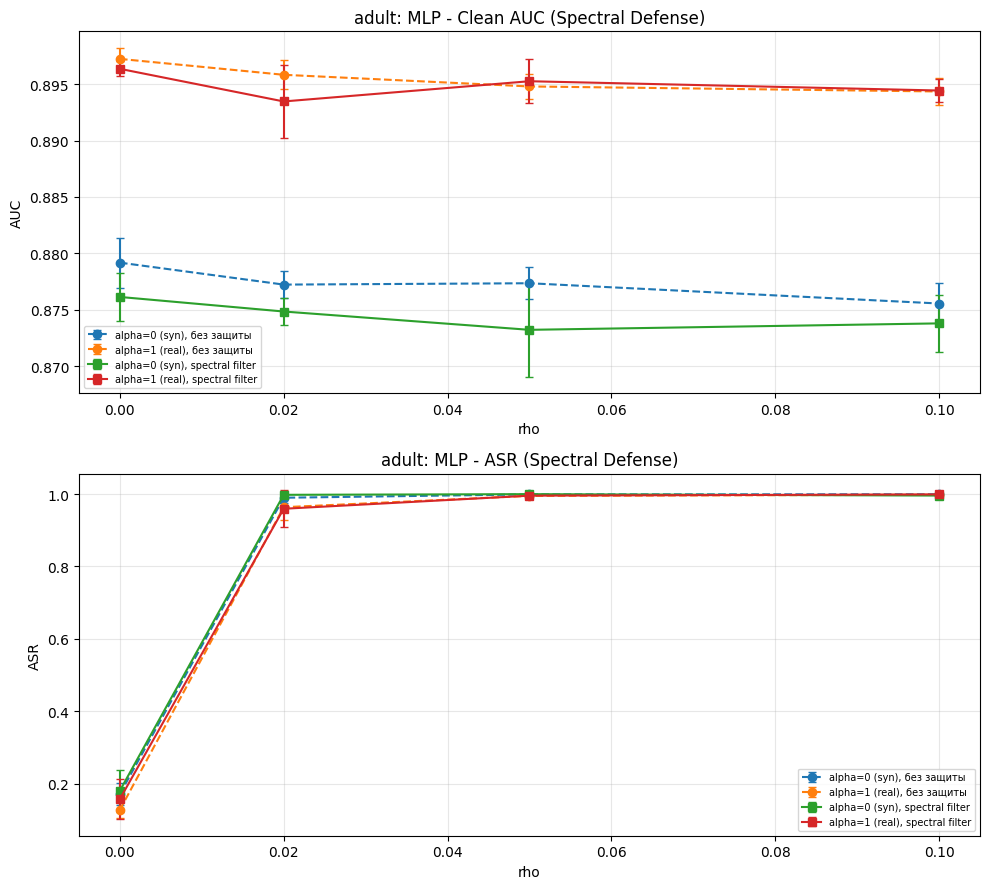

In [ ]:
# Spectral defense visualization
def plot_spectral_defense(df):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        fig, axes = plt.subplots(2, 1, figsize=(10, 9))

        for defended, ls, marker, lbl in [
            ('none', '--', 'o', 'без защиты'),
            ('spectral', '-', 's', 'spectral filter')
        ]:
            for alpha in [0.0, 1.0]:
                sub = ds[(ds['defense']==defended) & (ds['alpha']==alpha)]
                tag = f'alpha={alpha:.0f} ({"real" if alpha==1.0 else "syn"}), {lbl}'

                auc_agg = sub.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                axes[0].errorbar(auc_agg['rho'], auc_agg['mean'], yerr=auc_agg['std'],
                                 marker=marker, capsize=3, linestyle=ls, label=tag)

                asr_agg = sub.groupby('rho')['asr'].agg(['mean','std']).reset_index()
                axes[1].errorbar(asr_agg['rho'], asr_agg['mean'], yerr=asr_agg['std'],
                                 marker=marker, capsize=3, linestyle=ls, label=tag)

        axes[0].set_title(f'{name}: MLP - Clean AUC (Spectral Defense)')
        axes[0].set_xlabel('rho'); axes[0].set_ylabel('AUC')
        axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

        axes[1].set_title(f'{name}: MLP - ASR (Spectral Defense)')
        axes[1].set_xlabel('rho'); axes[1].set_ylabel('ASR')
        axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'figures/{name}_spectral_defense.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_spectral_defense(spectral_results)

## A2.6. Проверка гипотезы H3: зависимость эффективности защит от источника данных

**H3**: эффективность базовых контрмер (sanitization, cleanlab, spectral filtering)
зависит от типа обучающих данных (real vs synthetic).

In [ ]:
def check_h3(san_df, spectral_df=None):
    """Check H3: does defense effectiveness depend on data source?"""
    print('  ГИПОТЕЗА H3: ЭФФЕКТИВНОСТЬ ЗАЩИТ vs ИСТОЧНИК ДАННЫХ')

    # Sanitization analysis
    print('\nSanitization ')
    for name in san_df['dataset'].unique():
        ds = san_df[san_df['dataset'] == name]
        for mname in ['LogReg', 'XGBoost']:
            for alpha in [0.0, 1.0]:
                tag = 'real' if alpha == 1.0 else 'syn'

                # AUC at rho=10% without defense
                no_def = ds[(ds['model']==mname) & (ds['alpha']==alpha) &
                            (ds['defense']=='none') & (ds['rho']==0.10)]['test_auc'].mean()
                # AUC at rho=10% with defense
                w_def = ds[(ds['model']==mname) & (ds['alpha']==alpha) &
                           (ds['defense']=='sanitize') & (ds['rho']==0.10)]['test_auc'].mean()
                recovery = w_def - no_def
                print(f'  [{name}] {mname} alpha={alpha:.0f} ({tag}): '
                      f'no_def={no_def:.4f}, sanitize={w_def:.4f}, '
                      f'recovery={recovery:+.4f}')

    # Spectral filtering analysis (if available)
    if spectral_df is not None and len(spectral_df) > 0:
        print('\nSpectral Filtering (MLP, Backdoor) ')
        for name in spectral_df['dataset'].unique():
            ds = spectral_df[spectral_df['dataset'] == name]
            for alpha in [0.0, 1.0]:
                tag = 'real' if alpha == 1.0 else 'syn'
                # ASR at rho=10%
                no_def_asr = ds[(ds['alpha']==alpha) & (ds['defense']=='none') &
                                (ds['rho']==0.10)]['asr'].mean()
                w_def_asr = ds[(ds['alpha']==alpha) & (ds['defense']=='spectral') &
                               (ds['rho']==0.10)]['asr'].mean()
                asr_reduction = no_def_asr - w_def_asr
                print(f'  [{name}] MLP alpha={alpha:.0f} ({tag}): '
                      f'ASR no_def={no_def_asr:.4f}, spectral={w_def_asr:.4f}, '
                      f'ASR reduction={asr_reduction:+.4f}')


# Load sanitization results
try:
    san_loaded = pd.read_csv('results/defense_sanitize.csv')
except FileNotFoundError:
    san_loaded = san_all

check_h3(san_loaded, spectral_results)

  ГИПОТЕЗА H3: ЭФФЕКТИВНОСТЬ ЗАЩИТ vs ИСТОЧНИК ДАННЫХ

Sanitization 
  [adult] LogReg alpha=0 (syn): no_def=0.8381, sanitize=0.8427, recovery=+0.0046
  [adult] LogReg alpha=1 (real): no_def=0.8518, sanitize=0.8524, recovery=+0.0006
  [adult] XGBoost alpha=0 (syn): no_def=0.8766, sanitize=0.8748, recovery=-0.0018
  [adult] XGBoost alpha=1 (real): no_def=0.9126, sanitize=0.9107, recovery=-0.0019

Spectral Filtering (MLP, Backdoor) 
  [adult] MLP alpha=0 (syn): ASR no_def=0.9997, spectral=0.9961, ASR reduction=+0.0037
  [adult] MLP alpha=1 (real): ASR no_def=0.9983, spectral=0.9993, ASR reduction=-0.0010


## A3. Additional: Privacy Metrics (MIA, DCR, NNDR)

In [ ]:
from sklearn.neighbors import NearestNeighbors

def compute_dcr_nndr(syn_arr, real_arr):
    nn = NearestNeighbors(n_neighbors=2, metric='euclidean').fit(real_arr)
    dists, _ = nn.kneighbors(syn_arr)
    dcr = dists[:, 0]
    nndr = dists[:, 0] / (dists[:, 1] + 1e-10)
    return dcr, nndr

def membership_inference_attack(name, label_encoders, scaler_obj):
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)
    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')
    syn_df = pd.read_csv(f'data/synthetic/{name}_syn.csv')
    target_col = meta['target_col']

    for c in meta['cat_cols']:
        if c in syn_df.columns and c in label_encoders:
            le = label_encoders[c]
            syn_df[c] = syn_df[c].clip(0, len(le.classes_) - 1).astype(int)

    real_arr = train_df.drop(columns=[target_col], errors='ignore').values.astype(float)
    syn_arr  = syn_df.drop(columns=[target_col], errors='ignore').values.astype(float)
    real_arr[:, meta['num_idx']] = scaler_obj.transform(real_arr[:, meta['num_idx']])
    syn_arr[:, meta['num_idx']]  = scaler_obj.transform(syn_arr[:, meta['num_idx']])

    # Simple MIA
    nn_syn = NearestNeighbors(n_neighbors=1).fit(syn_arr)
    d_members, _ = nn_syn.kneighbors(real_arr)
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    d_nonmembers, _ = nn_syn.kneighbors(X_test)

    threshold = np.median(np.concatenate([d_members.ravel(), d_nonmembers.ravel()]))
    tp = (d_members.ravel() < threshold).mean()
    fp = (d_nonmembers.ravel() < threshold).mean()
    advantage = abs(tp - fp)

    print(f'[{name}] MIA - TP: {tp:.4f}, FP: {fp:.4f}, Advantage: {advantage:.4f}')

    dcr, nndr = compute_dcr_nndr(syn_arr, real_arr)
    print(f'[{name}] DCR  - mean: {dcr.mean():.4f}, median: {np.median(dcr):.4f}, '
          f'min: {dcr.min():.4f}, 5th pctl: {np.percentile(dcr, 5):.4f}')
    print(f'[{name}] NNDR - mean: {nndr.mean():.4f}, median: {np.median(nndr):.4f}')

    return {'dataset': name, 'mia_tp': tp, 'mia_fp': fp, 'mia_advantage': advantage,
            'dcr_mean': dcr.mean(), 'dcr_median': np.median(dcr), 'dcr_min': dcr.min(),
            'dcr_5pctl': np.percentile(dcr, 5), 'nndr_mean': nndr.mean(), 'nndr_median': np.median(nndr)}

privacy_rows = []
for ds_name, ds_info in DATASETS.items():
    privacy_rows.append(membership_inference_attack(ds_name, ds_info['le'], ds_info['scaler']))

privacy_all = pd.DataFrame(privacy_rows)
privacy_all.to_csv('results/privacy_metrics.csv', index=False)
print('\n' + privacy_all.to_string(index=False))

[adult] MIA - TP: 0.5003, FP: 0.4992, Advantage: 0.0011
[adult] DCR  - mean: 1.8985, median: 1.6183, min: 0.0016, 5th pctl: 0.2220
[adult] NNDR - mean: 0.8334, median: 0.8927
[bank] MIA - TP: 0.5018, FP: 0.4945, Advantage: 0.0073
[bank] DCR  - mean: 1.8521, median: 1.6240, min: 0.0108, 5th pctl: 0.4993
[bank] NNDR - mean: 0.8721, median: 0.9206

dataset   mia_tp   mia_fp  mia_advantage  dcr_mean  dcr_median  dcr_min  dcr_5pctl  nndr_mean  nndr_median
  adult 0.500256 0.499156       0.001100  1.898542    1.618340 0.001599   0.222022   0.833413     0.892682
   bank 0.501821 0.494538       0.007283  1.852144    1.623964 0.010843   0.499335   0.872128     0.920577


## Final Summary

In [ ]:
print('EXPERIMENT COMPLETE')

print('\nBaselines ')
print(results_all.to_string(index=False))

print('\nCore: Label Flipping Summary ')
print(lf_summary.to_string(index=False))

print('\nCore: Feature Perturbation Summary (lambda=1.0) ')
print(fp_summary.to_string(index=False))

print('\nPrivacy ')
print(privacy_all.to_string(index=False))

print('\nFiles saved ')
import glob
for f in sorted(glob.glob('results/*.csv')) + sorted(glob.glob('figures/*.png')):
    print(f'  {f}')

print('\n Core benchmark complete.')

EXPERIMENT COMPLETE

Baselines 
dataset  alpha   model  test_auc  test_acc  test_f1  val_auc
  adult   0.00  LogReg  0.842027  0.814371 0.591968 0.838935
  adult   0.00 XGBoost  0.880624  0.822202 0.650573 0.874003
  adult   0.25  LogReg  0.847717  0.820820 0.582469 0.845717
  adult   0.25 XGBoost  0.904422  0.852449 0.678488 0.906471
  adult   0.50  LogReg  0.852754  0.823737 0.577631 0.851769
  adult   0.50 XGBoost  0.912413  0.861661 0.694680 0.915713
  adult   0.75  LogReg  0.854791  0.824505 0.562906 0.855702
  adult   0.75 XGBoost  0.917411  0.867035 0.706640 0.921532
  adult   1.00  LogReg  0.854843  0.826654 0.558812 0.856805
  adult   1.00 XGBoost  0.921734  0.866114 0.696590 0.926870
   bank   0.00  LogReg  0.916757  0.911022 0.477548 0.904888
   bank   0.00 XGBoost  0.857319  0.902525 0.459987 0.846556
   bank   0.25  LogReg  0.924590  0.911143 0.484507 0.913634
   bank   0.25 XGBoost  0.939479  0.915878 0.550292 0.930147
   bank   0.50  LogReg  0.928892  0.912357 0.499307 0